# Bevilgningsår-analyse: statlig samferdselsfinansiering 2005–2039

Leser direkte fra Google Sheets (publisert som CSV). Eneste kilde til sannhet er
arket **Konsolidert_2005_2039** i regnearket – som blir manuelt korrigert og validert.

**Datakilder i arket:**
- SVV-prosjekter 2005-2013 (fra SVV-arket)
- Andre virksomheter 2005-2013 er innhentet ved AI og googling og justert til 2026 kroner
- Alle virksomheter 2014-2039 (fra pluss-arket): SVV, Nye Veier, Bane NOR, Avinor
- Placeholder-prosjekter: E39 Hordfast og E39 Møreaksen (status = `Dersom`)

**Metode:**
- Lineær fordeling av statlig andel over anleggsperioden (`oppstart_aar` → `aar_ferdig`)
- Alternativ metode: annen finansiering kan legges først i byggeperioden, før statlig bidrag
- ERTMS (`landsdel = HELE_LANDET`) kan inkluderes og fordeles på alle landsdeler etter befolkningsandel
- Manglende `total_2026kr` eller `statlig_andel` (verdi `-999`) ignoreres – vi bruker `statlig_2026kr` direkte
- Placeholder-prosjekter (`status = 'Dersom'`) ekskluderes som default

## 1. Konfigurasjon

In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import io

# ===== KONFIGURASJON =====
INKLUDER_DERSOM = False   # Sett True for å inkludere Hordfast/Møreaksen-placeholders
INKLUDER_ERTMS = False   # Sett True for å inkludere ERTMS fordeling
STATLIG_FINANSIERING_SIST = True  # Sett True for å la annen finansiering komme før statlig bidrag

ANALYSE_START = 2005
ANALYSE_SLUTT = 2039
VESTLAND_FYLKE_FOLK = 653_000  # Omtrentlig 2025-befolkning; oppdater ved behov

SHEETS_PUBLISHED_ID = '2PACX-1vTwThbTIdJy4uvp1RmmTilsrG6r1M2vLBvxEhcJMBXx187tzgIGVw8HigGRPup9QT1W0xaN8fYsFGj-'
SHEET_NAME = 'Konsolidert_2005_2039'
SHEET_GID = '1736874043'
SHEETS_CSV_URL = f'https://docs.google.com/spreadsheets/d/e/{SHEETS_PUBLISHED_ID}/pub'



plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'axes.grid': True,
    'grid.alpha': 0.25, 'axes.axisbelow': True,
})

FARGER = {'ØST':'#185FA5','VEST':'#D85A30','NORD':'#0F6E56','MIDT':'#7F77DD','SØR':'#888780'}
RNAVN = {'ØST':'Østlandet','VEST':'Vestlandet','NORD':'Nord-Norge','MIDT':'Trøndelag','SØR':'Sørlandet'}
FOLK = {'ØST':2_870_000,'VEST':1_420_000,'NORD':480_000,'MIDT':480_000,'SØR':320_000}
TOTAL_FOLK = sum(FOLK.values())
BEF = {ld: FOLK[ld]/TOTAL_FOLK*100 for ld in FOLK}
REGIONS = ['ØST','VEST','NORD','MIDT','SØR']

## 2. Last data fra Google Sheets

Henter publisert CSV-versjon av fanen `Konsolidert_2005_2039` via Google Sheets sitt publiserte eksport-endepunkt. Hvis det er nettverksproblemer må arket være publisert på web og `SHEET_GID` peke til riktig fane.

In [401]:
# Hent CSV fra publisert Google Sheets-fane
params = {'gid': SHEET_GID, 'single': 'true', 'output': 'csv'}
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'}
resp = requests.get(SHEETS_CSV_URL, params=params, headers=headers, timeout=60)
resp.raise_for_status()
resp.encoding = 'utf-8'

content_type = resp.headers.get('content-type', '')
if 'text/csv' not in content_type.lower():
    raise RuntimeError(
        f'Forventet CSV fra Google Sheets, fikk {content_type!r}. '
        'Sjekk at arket er publisert og at SHEET_GID er riktig.'
    )

print(f'Hentet {len(resp.content):,} bytes CSV fra Google Sheets')

# Les arket. Header på rad 5 (etter 4 metadata-rader)
df_raw = pd.read_csv(io.StringIO(resp.text), header=4)
print(f'Lest {len(df_raw)} rader fra arket "{SHEET_NAME}"')
print()
print('Kolonner:', list(df_raw.columns))
print()
print('Status-fordeling:')
print(df_raw['status'].value_counts())

Hentet 16,232 bytes CSV fra Google Sheets
Lest 129 rader fra arket "Konsolidert_2005_2039"

Kolonner: ['virksomhet', 'status', 'navn', 'landsdel', 'fylke', 'vedtak_aar', 'oppstart_aar', 'aar_ferdig', 'anleggsperiode', 'total_2026kr', 'statlig_andel', 'statlig_2026kr', 'val_kode', 'kilde', 'kommentar']

Status-fordeling:
status
Ferdig    94
Bygges    33
Dersom     2
Name: count, dtype: int64


## 3. Rens og filtrer

Konverter manglende verdier (`-999`, `'ukjent'`) til `NaN`. Filtrer ut `Dersom`-prosjekter
hvis `INKLUDER_DERSOM = False`, og filtrer ut ERTMS-raden hvis `INKLUDER_ERTMS = False`.

In [402]:
df = df_raw.copy()

def parse_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == '' or text.lower() == 'nan':
        return np.nan
    text = (
        text.replace('\xa0', '')
            .replace(' ', '')
            .replace('%', '')
            .replace(',', '.')
    )
    return pd.to_numeric(text, errors='coerce')

# Numeriske kolonner som renses likt overalt (parse + -999 -> NaN)
NUM_KOLONNER = ['total_2026kr', 'statlig_andel', 'statlig_2026kr',
                'vedtak_aar', 'oppstart_aar', 'aar_ferdig', 'anleggsperiode']

def rens_numeriske(frame, kolonner=NUM_KOLONNER):
    """Parser numeriske kolonner og konverterer -999 til NaN. Endrer frame in-place og returnerer den."""
    for c in kolonner:
        if c in frame.columns:
            frame[c] = frame[c].map(parse_number)
            frame.loc[frame[c] == -999, c] = np.nan
    return frame

# Rens numeriske kolonner i hoveddataene
rens_numeriske(df)

# Konverter 'ukjent' til NaN i tekstkolonner
for c in ['fylke', 'kilde', 'val_kode']:
    if c in df.columns:
        df.loc[df[c].astype(str).str.lower() == 'ukjent', c] = np.nan

# Felles utvalgskriterium for placeholder-prosjekter (Hordfast/Møreaksen mv.)
DERSOM_MASK = df_raw['status'] == 'Dersom'

# Filtrer ut Dersom-prosjekter hvis ikke ekskludert
if not INKLUDER_DERSOM:
    n_dersom = (df['status'] == 'Dersom').sum()
    df = df[df['status'] != 'Dersom'].copy()
    print(f'Filtrerte bort {n_dersom} "Dersom"-prosjekter (sett INKLUDER_DERSOM = True for å ta med)')
else:
    print(f'Inkluderer {(df["status"]=="Dersom").sum()} "Dersom"-prosjekter')

# Filtrer ut ERTMS-raden hvis ikke inkludert
ertms_mask = df['navn'].astype(str).str.contains('ERTMS', case=False, na=False)
if not INKLUDER_ERTMS:
    n_ertms = ertms_mask.sum()
    df = df[~ertms_mask].copy()
    print(f'Filtrerte bort {n_ertms} ERTMS-rad (sett INKLUDER_ERTMS = True for å ta med)')
else:
    print(f'Inkluderer {ertms_mask.sum()} ERTMS-rad')

print(f'Antall prosjekter etter filtrering: {len(df)}')
print()
print('Per virksomhet:')
print(df['virksomhet'].value_counts())
print()
print('Per landsdel:')
print(df['landsdel'].value_counts())


Filtrerte bort 2 "Dersom"-prosjekter (sett INKLUDER_DERSOM = True for å ta med)
Filtrerte bort 1 ERTMS-rad (sett INKLUDER_ERTMS = True for å ta med)
Antall prosjekter etter filtrering: 126

Per virksomhet:
virksomhet
SVV       95
BANE      21
NV         8
AVINOR     2
Name: count, dtype: int64

Per landsdel:
landsdel
ØST     57
VEST    32
NORD    22
MIDT    10
SØR      5
Name: count, dtype: int64


## 4. Bevilgningsårfordeling

Hvert prosjekt fordeles over anleggsperioden. Som standard fordeles statlig bidrag lineært. Hvis `STATLIG_FINANSIERING_SIST = True`, holdes total finansiering per prosjektår lik, men annen finansiering legges først i perioden før statlig bidrag føres. Hvis ERTMS er inkludert, fordeles `HELE_LANDET` på alle landsdeler etter befolkningsandel.

In [403]:
def fordel_per_aar(prosjekt):
    if pd.isna(prosjekt['oppstart_aar']) or pd.isna(prosjekt['aar_ferdig']):
        return {}
    s, e = int(prosjekt['oppstart_aar']), int(prosjekt['aar_ferdig'])
    aar_liste = list(range(s, e + 1))
    n = len(aar_liste)
    if n == 0 or pd.isna(prosjekt['statlig_2026kr']):
        return {}

    statlig_belop = prosjekt['statlig_2026kr']
    if not STATLIG_FINANSIERING_SIST:
        return {a: statlig_belop / n for a in aar_liste}

    total_belop = prosjekt.get('total_2026kr', np.nan)
    statlig_andel = prosjekt.get('statlig_andel', np.nan)
    if (
        pd.isna(total_belop)
        or pd.isna(statlig_andel)
        or statlig_andel >= 100
        or total_belop <= 0
        or statlig_belop >= total_belop
    ):
        return {a: statlig_belop / n for a in aar_liste}

    total_per_aar = total_belop / n
    annen_finansiering_igjen = max(total_belop - statlig_belop, 0)
    statlig_igjen = statlig_belop
    fordeling = {}
    for aar in aar_liste:
        annen_i_aar = min(total_per_aar, annen_finansiering_igjen)
        statlig_i_aar = min(total_per_aar - annen_i_aar, statlig_igjen)
        fordeling[aar] = statlig_i_aar
        annen_finansiering_igjen -= annen_i_aar
        statlig_igjen -= statlig_i_aar
    return fordeling

aarlig = {r: {} for r in REGIONS}
for _, p in df.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] == 'HELE_LANDET':
            for r in REGIONS:
                aarlig[r][aar_p] = aarlig[r].get(aar_p, 0) + belop * FOLK[r] / TOTAL_FOLK
        elif p['landsdel'] in REGIONS:
            aarlig[p['landsdel']][aar_p] = aarlig[p['landsdel']].get(aar_p, 0) + belop

aarlig_df = pd.DataFrame(aarlig).fillna(0).sort_index()
aarlig_df['TOTAL'] = aarlig_df[REGIONS].sum(axis=1)
aarlig_df = aarlig_df.reindex(range(ANALYSE_START, ANALYSE_SLUTT + 1), fill_value=0)
aar_liste_test = fordel_per_aar(df[df['statlig_andel'].lt(100)].iloc[0]) if (df['statlig_andel'].lt(100)).any() else {}
print(f'STATLIG_FINANSIERING_SIST = {STATLIG_FINANSIERING_SIST}')
print(f'Kontrollsum testprosjekt: {sum(aar_liste_test.values()):.1f}' if aar_liste_test else 'Ingen delvis finansierte testprosjekter')
aarlig_df.round(0).head(15)

STATLIG_FINANSIERING_SIST = True
Kontrollsum testprosjekt: 3445.0


,ØST,VEST,NORD,MIDT,SØR,TOTAL
2005,521.0,0.0,0.0,0.0,0.0,521.0
2006,1186.0,1148.0,0.0,0.0,0.0,2334.0
2007,3786.0,1148.0,0.0,0.0,313.0,5247.0
2008,4465.0,1148.0,0.0,0.0,1566.0,7179.0
2009,4630.0,1624.0,0.0,442.0,1566.0,8262.0
2010,3179.0,476.0,75.0,621.0,0.0,4350.0
2011,5913.0,1022.0,479.0,627.0,0.0,8040.0
2012,9432.0,1547.0,1181.0,296.0,0.0,12457.0
2013,9124.0,1486.0,1228.0,178.0,0.0,12017.0
2014,16524.0,2293.0,1505.0,178.0,0.0,20500.0


## 5. Statlig bevilgning per person

Beregner gjennomsnittlig årlig statlig bevilgning per innbygger per landsdel, både for hele analyseperioden og for 5-årsperioder.

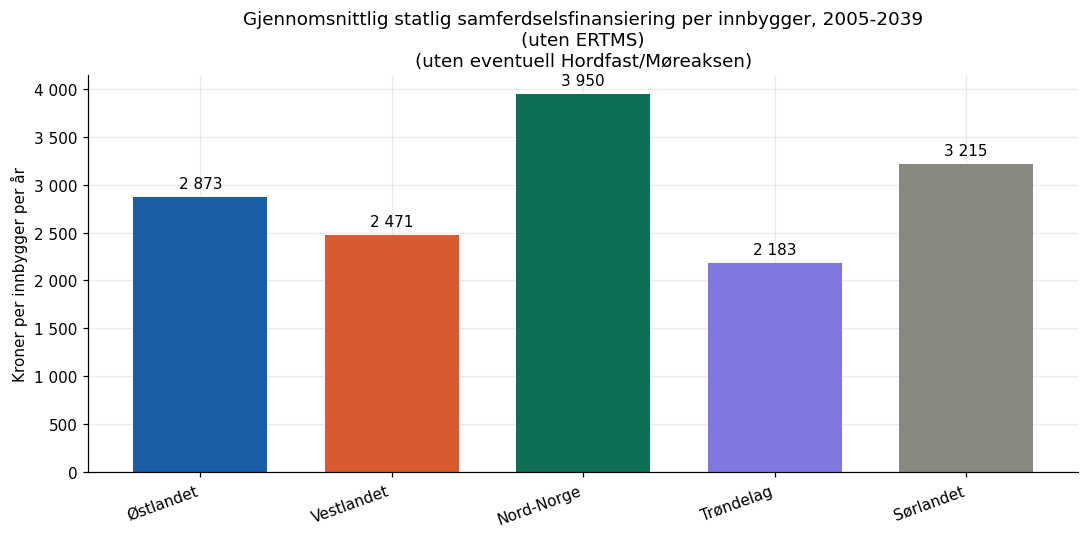

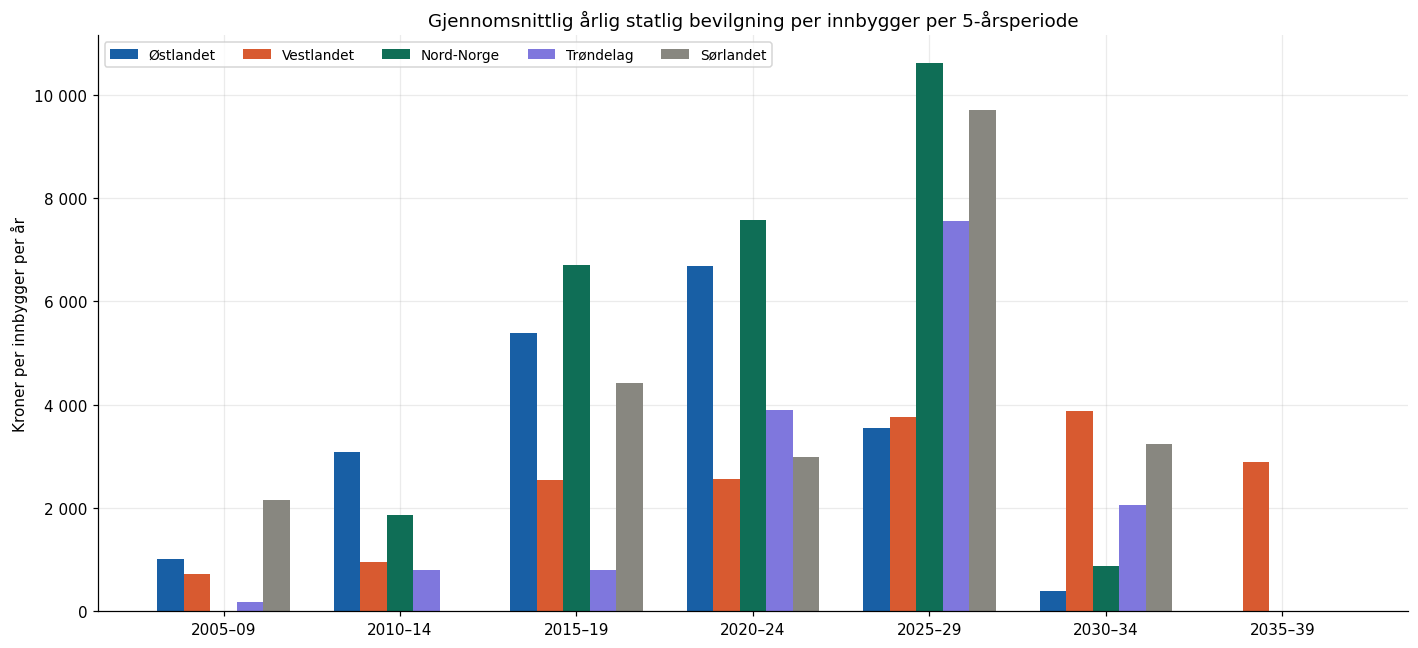

,ØST,VEST,NORD,MIDT,SØR
2005–09,1017.0,714.0,0.0,184.0,2153.0
2010–14,3078.0,961.0,1862.0,792.0,0.0
2015–19,5393.0,2548.0,6713.0,793.0,4428.0
2020–24,6683.0,2561.0,7572.0,3894.0,2985.0
2025–29,3554.0,3753.0,10620.0,7557.0,9710.0
2030–34,388.0,3868.0,883.0,2062.0,3229.0
2035–39,0.0,2890.0,0.0,0.0,0.0


In [404]:
per_person_df = aarlig_df[REGIONS].copy()
for ld in REGIONS:
    per_person_df[ld] = per_person_df[ld] * 1_000_000 / FOLK[ld]

snitt_per_person = per_person_df.mean().reindex(REGIONS)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [RNAVN[ld] for ld in REGIONS],
    snitt_per_person.values,
    color=[FARGER[ld] for ld in REGIONS],
    width=0.7,
)

for bar, value in zip(bars, snitt_per_person.values):
    ax.annotate(
        f'{value:,.0f}'.replace(',', ' '),
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        fontsize=10,
    )

ax.set_ylabel('Kroner per innbygger per år')
tittel = f'Gjennomsnittlig statlig samferdselsfinansiering per innbygger, {ANALYSE_START}-{ANALYSE_SLUTT}'
if not INKLUDER_ERTMS:
    tittel += '\n(uten ERTMS)'
if not INKLUDER_DERSOM:
    tittel += '\n(uten eventuell Hordfast/Møreaksen)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

femaar_perioder = [(s, min(s + 4, ANALYSE_SLUTT)) for s in range(ANALYSE_START, ANALYSE_SLUTT + 1, 5)]
femaar_labels = [f'{s}–{str(e)[-2:]}' for s, e in femaar_perioder]
femaar_per_person = pd.DataFrame(
    {label: per_person_df.loc[s:e, REGIONS].mean() for (s, e), label in zip(femaar_perioder, femaar_labels)}
).T

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(femaar_per_person))
bredde = 0.15
forskyvning = (np.arange(len(REGIONS)) - (len(REGIONS) - 1) / 2) * bredde

for i, ld in enumerate(REGIONS):
    ax.bar(
        x + forskyvning[i],
        femaar_per_person[ld].values,
        width=bredde,
        label=RNAVN[ld],
        color=FARGER[ld],
    )

ax.set_xticks(x)
ax.set_xticklabels(femaar_labels)
ax.set_ylabel('Kroner per innbygger per år')
ax.set_title('Gjennomsnittlig årlig statlig bevilgning per innbygger per 5-årsperiode', fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
ax.legend(ncol=5, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

femaar_per_person.round(0)

### Sammenligning: Østlandet og Vestland fylke mot resten

Sammenligner gjennomsnittlig årlig statlig samferdselsfinansiering per innbygger for Østlandet mot resten av landet, og Vestland fylke mot resten av landet.

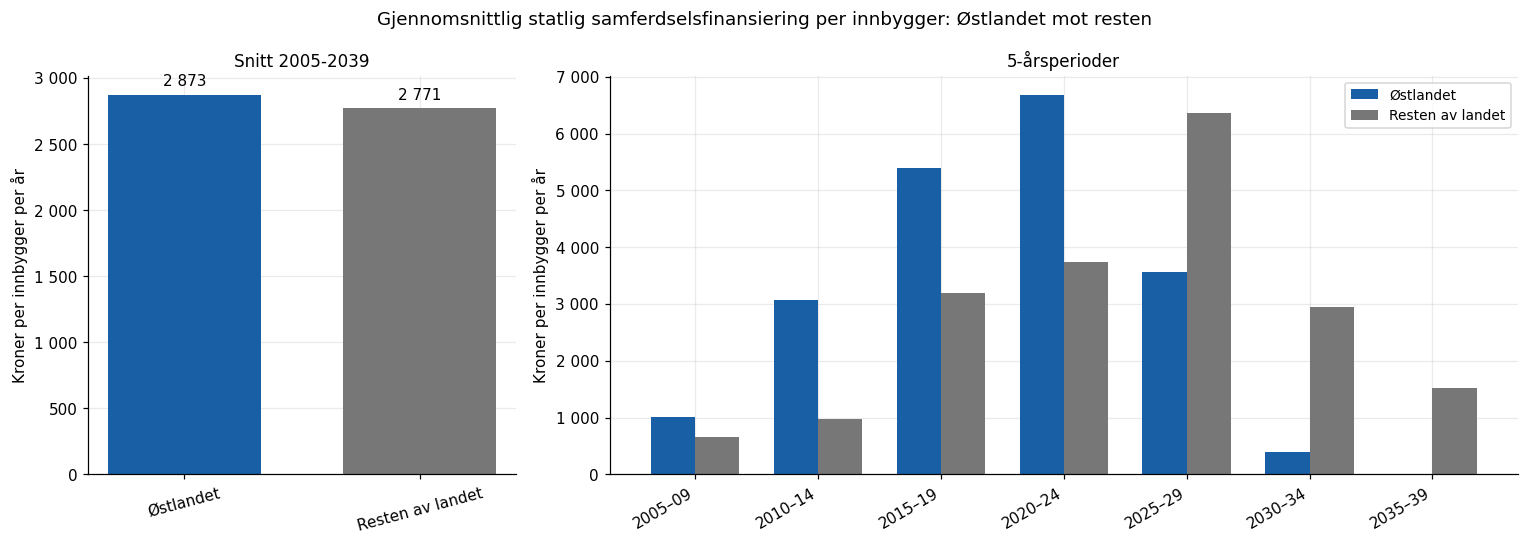

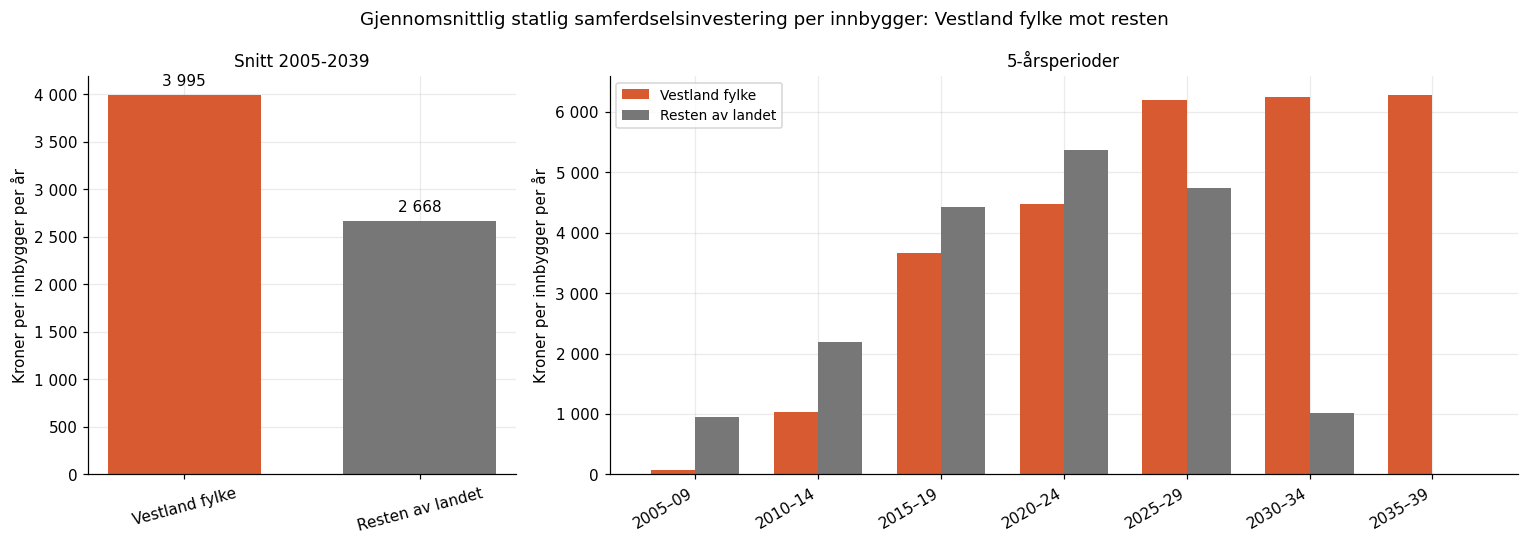

Vestland fylke befolkning brukt: 653 000
Prosjekter med helt eller delvis Vestland fylke: 20


,Østlandet vs resten,Vestland fylke vs resten
Resten av landet,2771.0,2668.0
Vestland fylke,NaN,3995.0
Østlandet,2873.0,NaN


In [405]:
# Østlandet mot resten av landet
ost_vs_resten_df = pd.DataFrame({
    'Østlandet': aarlig_df['ØST'] * 1_000_000 / FOLK['ØST'],
    'Resten av landet': aarlig_df[[ld for ld in REGIONS if ld != 'ØST']].sum(axis=1) * 1_000_000 / (TOTAL_FOLK - FOLK['ØST']),
})

ost_vs_resten_femaar = pd.DataFrame(
    {label: ost_vs_resten_df.loc[s:e].mean() for (s, e), label in zip(femaar_perioder, femaar_labels)}
).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [0.8, 1.7]})
snitt_ost = ost_vs_resten_df.mean()
bars = axes[0].bar(snitt_ost.index, snitt_ost.values, color=[FARGER['ØST'], '#777777'], width=0.65)
for bar, value in zip(bars, snitt_ost.values):
    axes[0].annotate(f'{value:,.0f}'.replace(',', ' '),
                     xy=(bar.get_x() + bar.get_width()/2, value),
                     xytext=(0, 6), textcoords='offset points', ha='center', fontsize=10)
axes[0].set_ylabel('Kroner per innbygger per år')
axes[0].set_title(f'Snitt {ANALYSE_START}-{ANALYSE_SLUTT}', fontsize=11, fontweight='500')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
axes[0].tick_params(axis='x', rotation=15)

x = np.arange(len(ost_vs_resten_femaar))
bredde = 0.36
axes[1].bar(x - bredde/2, ost_vs_resten_femaar['Østlandet'], width=bredde, color=FARGER['ØST'], label='Østlandet')
axes[1].bar(x + bredde/2, ost_vs_resten_femaar['Resten av landet'], width=bredde, color='#777777', label='Resten av landet')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ost_vs_resten_femaar.index, rotation=30, ha='right')
axes[1].set_ylabel('Kroner per innbygger per år')
axes[1].set_title('5-årsperioder', fontsize=11, fontweight='500')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
axes[1].legend(fontsize=9)
plt.suptitle('Gjennomsnittlig statlig samferdselsfinansiering per innbygger: Østlandet mot resten', fontsize=12, fontweight='500')
plt.tight_layout()
plt.show()

# Vestland fylke mot resten av landet

def fylke_andel(fylkeverdi, fylkesnavn):
    fylker = [f.strip() for f in str(fylkeverdi).split('/') if f.strip()]
    if not fylker:
        return 0
    return sum(f.lower() == fylkesnavn.lower() for f in fylker) / len(fylker)

vestland_aarlig = {}
for _, p in df.iterrows():
    andel_vestland = fylke_andel(p.get('fylke', ''), 'Vestland')
    if andel_vestland <= 0 or pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        vestland_aarlig[aar_p] = vestland_aarlig.get(aar_p, 0) + belop * andel_vestland

vestland_fylke_df = pd.DataFrame(index=aarlig_df.index)
vestland_fylke_df['Vestland fylke'] = pd.Series(vestland_aarlig).reindex(aarlig_df.index, fill_value=0)
vestland_fylke_df['Resten av landet'] = aarlig_df['TOTAL'] - vestland_fylke_df['Vestland fylke']
vestland_fylke_per_person = pd.DataFrame({
    'Vestland fylke': vestland_fylke_df['Vestland fylke'] * 1_000_000 / VESTLAND_FYLKE_FOLK,
    'Resten av landet': vestland_fylke_df['Resten av landet'] * 1_000_000 / (TOTAL_FOLK - VESTLAND_FYLKE_FOLK),
})

vestland_fylke_femaar = pd.DataFrame(
    {label: vestland_fylke_per_person.loc[s:e].mean() for (s, e), label in zip(femaar_perioder, femaar_labels)}
).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [0.8, 1.7]})
snitt_vestland = vestland_fylke_per_person.mean()
bars = axes[0].bar(snitt_vestland.index, snitt_vestland.values, color=[FARGER['VEST'], '#777777'], width=0.65)
for bar, value in zip(bars, snitt_vestland.values):
    axes[0].annotate(f'{value:,.0f}'.replace(',', ' '),
                     xy=(bar.get_x() + bar.get_width()/2, value),
                     xytext=(0, 6), textcoords='offset points', ha='center', fontsize=10)
axes[0].set_ylabel('Kroner per innbygger per år')
axes[0].set_title(f'Snitt {ANALYSE_START}-{ANALYSE_SLUTT}', fontsize=11, fontweight='500')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
axes[0].tick_params(axis='x', rotation=15)

x = np.arange(len(vestland_fylke_femaar))
axes[1].bar(x - bredde/2, vestland_fylke_femaar['Vestland fylke'], width=bredde, color=FARGER['VEST'], label='Vestland fylke')
axes[1].bar(x + bredde/2, vestland_fylke_femaar['Resten av landet'], width=bredde, color='#777777', label='Resten av landet')
axes[1].set_xticks(x)
axes[1].set_xticklabels(vestland_fylke_femaar.index, rotation=30, ha='right')
axes[1].set_ylabel('Kroner per innbygger per år')
axes[1].set_title('5-årsperioder', fontsize=11, fontweight='500')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
axes[1].legend(fontsize=9)
plt.suptitle('Gjennomsnittlig statlig samferdselsinvestering per innbygger: Vestland fylke mot resten', fontsize=12, fontweight='500')
plt.tight_layout()
plt.show()

print(f'Vestland fylke befolkning brukt: {VESTLAND_FYLKE_FOLK:,}'.replace(',', ' '))
print(f'Prosjekter med helt eller delvis Vestland fylke: {(df["fylke"].astype(str).str.contains("Vestland", case=False, na=False)).sum()}')

sammenligning_sammendrag = pd.DataFrame({
    'Østlandet vs resten': snitt_ost.round(0),
    'Vestland fylke vs resten': snitt_vestland.round(0),
})
sammenligning_sammendrag

### Trendvurdering: VEST mot resten og landssnittet

Viser VEST i et trendperspektiv med 5-års glidende snitt per innbygger. Indeksplottet setter landssnittet til 100, slik at verdier over 100 betyr høyere statlig samferdselsfinansiering per innbygger enn landet samlet.

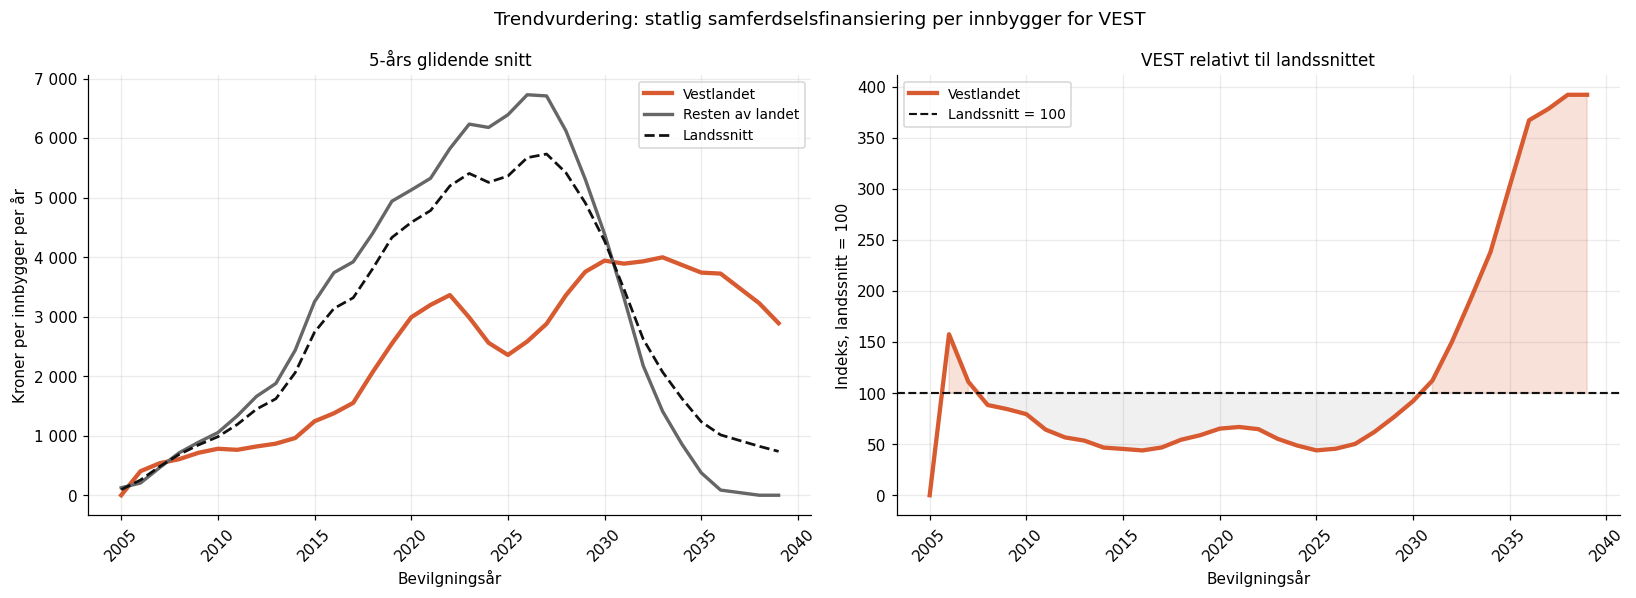

,VEST kr/innbygger/år,Resten kr/innbygger/år,Landssnitt kr/innbygger/år,VEST indeks mot landssnitt
2014–19,2392.0,4847.0,4221.0,57.0
2020–24,2561.0,6178.0,5256.0,49.0
2025–29,3753.0,5309.0,4913.0,76.0
2030–34,3868.0,858.0,1625.0,238.0
2035–39,2890.0,0.0,737.0,392.0


In [406]:
trend_vindu = 5

vest_trend_df = pd.DataFrame({
    'VEST': per_person_df['VEST'],
    'Resten av landet': aarlig_df[[ld for ld in REGIONS if ld != 'VEST']].sum(axis=1) * 1_000_000 / (TOTAL_FOLK - FOLK['VEST']),
    'Landssnitt': aarlig_df['TOTAL'] * 1_000_000 / TOTAL_FOLK,
})
vest_trend_glattet = vest_trend_df.rolling(window=trend_vindu, min_periods=1).mean()
vest_trend_indeks = vest_trend_glattet.div(vest_trend_glattet['Landssnitt'], axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(
    vest_trend_glattet.index,
    vest_trend_glattet['VEST'],
    color=FARGER['VEST'],
    lw=2.8,
    label='Vestlandet',
)
axes[0].plot(
    vest_trend_glattet.index,
    vest_trend_glattet['Resten av landet'],
    color='#666666',
    lw=2.2,
    label='Resten av landet',
)
axes[0].plot(
    vest_trend_glattet.index,
    vest_trend_glattet['Landssnitt'],
    color='#111111',
    lw=1.8,
    ls='--',
    label='Landssnitt',
)
axes[0].set_title(f'{trend_vindu}-års glidende snitt', fontsize=11, fontweight='500')
axes[0].set_ylabel('Kroner per innbygger per år')
axes[0].set_xlabel('Bevilgningsår')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(
    vest_trend_indeks.index,
    vest_trend_indeks['VEST'],
    color=FARGER['VEST'],
    lw=2.8,
    label='Vestlandet',
)
axes[1].axhline(100, color='#111111', lw=1.4, ls='--', label='Landssnitt = 100')
axes[1].fill_between(
    vest_trend_indeks.index,
    vest_trend_indeks['VEST'],
    100,
    where=vest_trend_indeks['VEST'] >= 100,
    color=FARGER['VEST'],
    alpha=0.18,
)
axes[1].fill_between(
    vest_trend_indeks.index,
    vest_trend_indeks['VEST'],
    100,
    where=vest_trend_indeks['VEST'] < 100,
    color='#888888',
    alpha=0.12,
)
axes[1].set_title('VEST relativt til landssnittet', fontsize=11, fontweight='500')
axes[1].set_ylabel('Indeks, landssnitt = 100')
axes[1].set_xlabel('Bevilgningsår')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Trendvurdering: statlig samferdselsfinansiering per innbygger for VEST', fontsize=12, fontweight='500')
plt.tight_layout()
plt.show()

trend_perioder = [(2014, 2019), (2020, 2024), (2025, 2029), (2030, 2034), (2035, 2039)]
trend_perioder = [(s, min(e, ANALYSE_SLUTT)) for s, e in trend_perioder if s <= ANALYSE_SLUTT]
trend_sammendrag = pd.DataFrame(
    {
        f'{s}–{str(e)[-2:]}': {
            'VEST kr/innbygger/år': vest_trend_df.loc[s:e, 'VEST'].mean(),
            'Resten kr/innbygger/år': vest_trend_df.loc[s:e, 'Resten av landet'].mean(),
            'Landssnitt kr/innbygger/år': vest_trend_df.loc[s:e, 'Landssnitt'].mean(),
            'VEST indeks mot landssnitt': vest_trend_df.loc[s:e, 'VEST'].mean() / vest_trend_df.loc[s:e, 'Landssnitt'].mean() * 100,
        }
        for s, e in trend_perioder
    }
).T

trend_sammendrag.round(0)

### Med Hordfast og Møreaksen

Samme beregning, men med placeholder-prosjektene E39 Hordfast og E39 Møreaksen lagt inn i årsfordelingen.

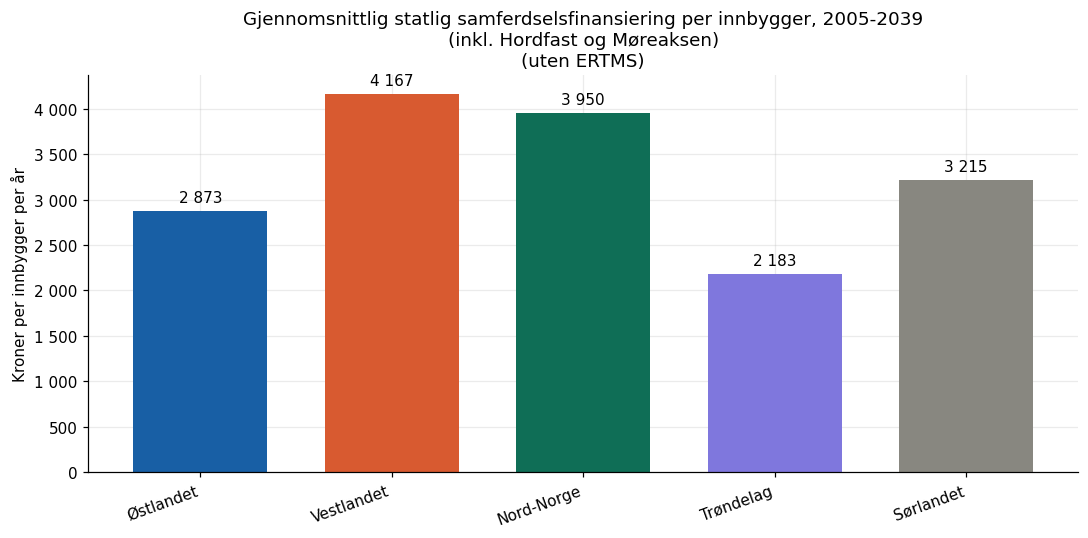

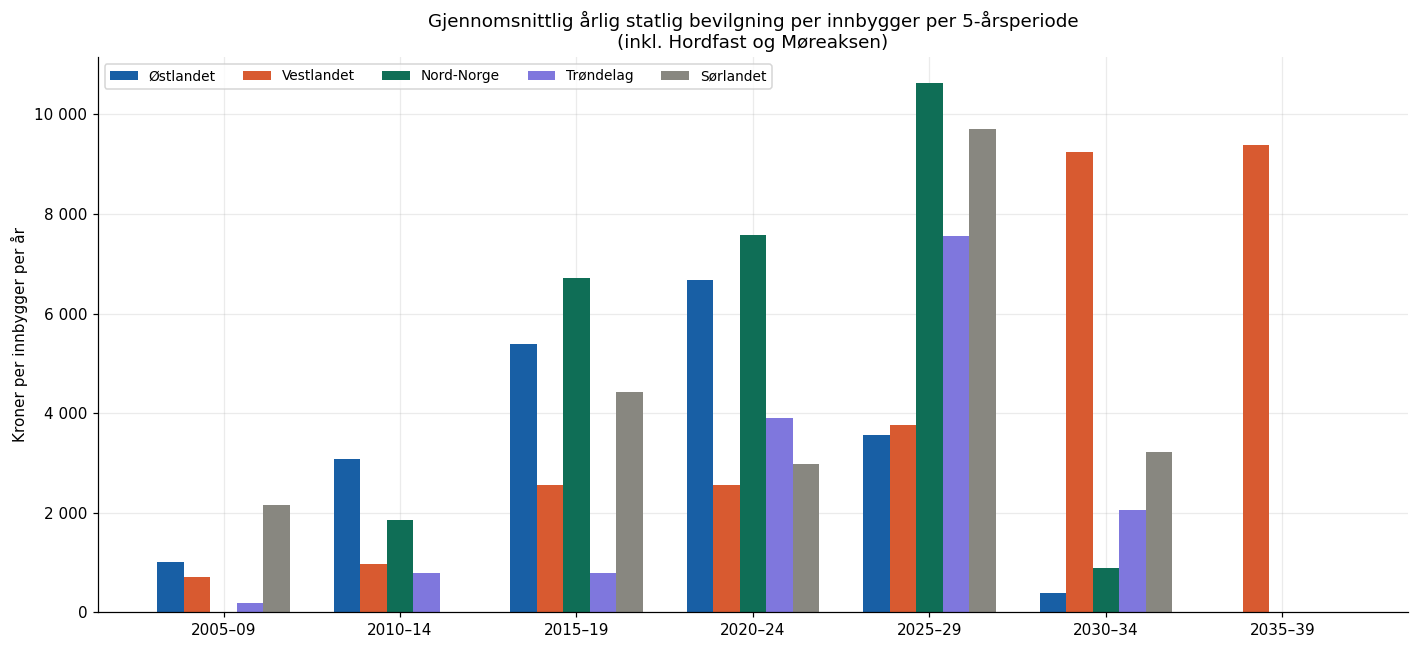

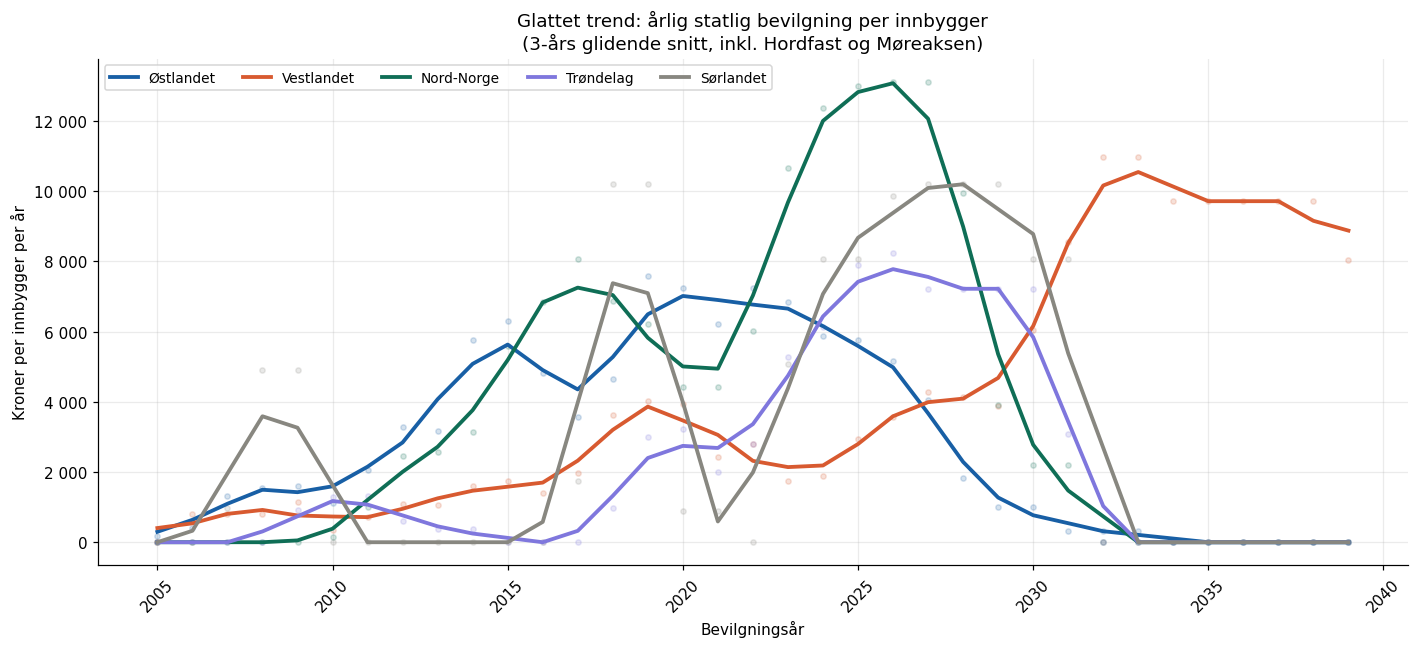

Inkluderte placeholder-prosjekter:
         navn landsdel  oppstart_aar  aar_ferdig  statlig_2026kr
 E39 Hordfast     VEST        2029.0      2039.0         62000.0
E39 Møreaksen     VEST        2029.0      2039.0         22300.0



,ØST,VEST,NORD,MIDT,SØR
2005–09,1017.0,714.0,0.0,184.0,2153.0
2010–14,3078.0,961.0,1862.0,792.0,0.0
2015–19,5393.0,2548.0,6713.0,793.0,4428.0
2020–24,6683.0,2561.0,7572.0,3894.0,2985.0
2025–29,3554.0,3753.0,10620.0,7557.0,9710.0
2030–34,388.0,9250.0,883.0,2062.0,3229.0
2035–39,0.0,9381.0,0.0,0.0,0.0


In [407]:
df_hordfast_moreaksen = rens_numeriske(df_raw[DERSOM_MASK].copy())

aarlig_hm = {ld: aarlig_df[ld].to_dict() for ld in REGIONS}
for _, p in df_hordfast_moreaksen.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] in REGIONS:
            aarlig_hm[p['landsdel']][aar_p] = aarlig_hm[p['landsdel']].get(aar_p, 0) + belop

aarlig_hm_df = pd.DataFrame(aarlig_hm).fillna(0).sort_index().reindex(range(ANALYSE_START, ANALYSE_SLUTT + 1), fill_value=0)
aarlig_hm_df['TOTAL'] = aarlig_hm_df[REGIONS].sum(axis=1)

per_person_hm_df = aarlig_hm_df[REGIONS].copy()
for ld in REGIONS:
    per_person_hm_df[ld] = per_person_hm_df[ld] * 1_000_000 / FOLK[ld]

snitt_per_person_hm = per_person_hm_df.mean().reindex(REGIONS)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [RNAVN[ld] for ld in REGIONS],
    snitt_per_person_hm.values,
    color=[FARGER[ld] for ld in REGIONS],
    width=0.7,
)

for bar, value in zip(bars, snitt_per_person_hm.values):
    ax.annotate(
        f'{value:,.0f}'.replace(',', ' '),
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        fontsize=10,
    )

ax.set_ylabel('Kroner per innbygger per år')
tittel = f'Gjennomsnittlig statlig samferdselsfinansiering per innbygger, {ANALYSE_START}-{ANALYSE_SLUTT}'
tittel += '\n(inkl. Hordfast og Møreaksen)'
if not INKLUDER_ERTMS:
    tittel += '\n(uten ERTMS)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

femaar_per_person_hm = pd.DataFrame(
    {label: per_person_hm_df.loc[s:e, REGIONS].mean() for (s, e), label in zip(femaar_perioder, femaar_labels)}
).T

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(femaar_per_person_hm))
bredde = 0.15
forskyvning = (np.arange(len(REGIONS)) - (len(REGIONS) - 1) / 2) * bredde

for i, ld in enumerate(REGIONS):
    ax.bar(
        x + forskyvning[i],
        femaar_per_person_hm[ld].values,
        width=bredde,
        label=RNAVN[ld],
        color=FARGER[ld],
    )

ax.set_xticks(x)
ax.set_xticklabels(femaar_labels)
ax.set_ylabel('Kroner per innbygger per år')
ax.set_title('Gjennomsnittlig årlig statlig bevilgning per innbygger per 5-årsperiode\n(inkl. Hordfast og Møreaksen)', fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
ax.legend(ncol=5, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

trend_per_person_hm = per_person_hm_df[REGIONS].rolling(window=3, center=True, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(13, 6))
for ld in REGIONS:
    ax.plot(
        trend_per_person_hm.index,
        trend_per_person_hm[ld],
        lw=2.5,
        color=FARGER[ld],
        label=RNAVN[ld],
    )
    ax.scatter(
        per_person_hm_df.index,
        per_person_hm_df[ld],
        s=12,
        color=FARGER[ld],
        alpha=0.18,
    )

ax.set_ylabel('Kroner per innbygger per år')
ax.set_xlabel('Bevilgningsår')
ax.set_title('Glattet trend: årlig statlig bevilgning per innbygger\n(3-års glidende snitt, inkl. Hordfast og Møreaksen)', fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
ax.legend(ncol=5, loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Inkluderte placeholder-prosjekter:')
print(df_hordfast_moreaksen[['navn', 'landsdel', 'oppstart_aar', 'aar_ferdig', 'statlig_2026kr']].to_string(index=False))
print()
femaar_per_person_hm.round(0)


## 6. Stablet søylediagram: bevilgning per landsdel

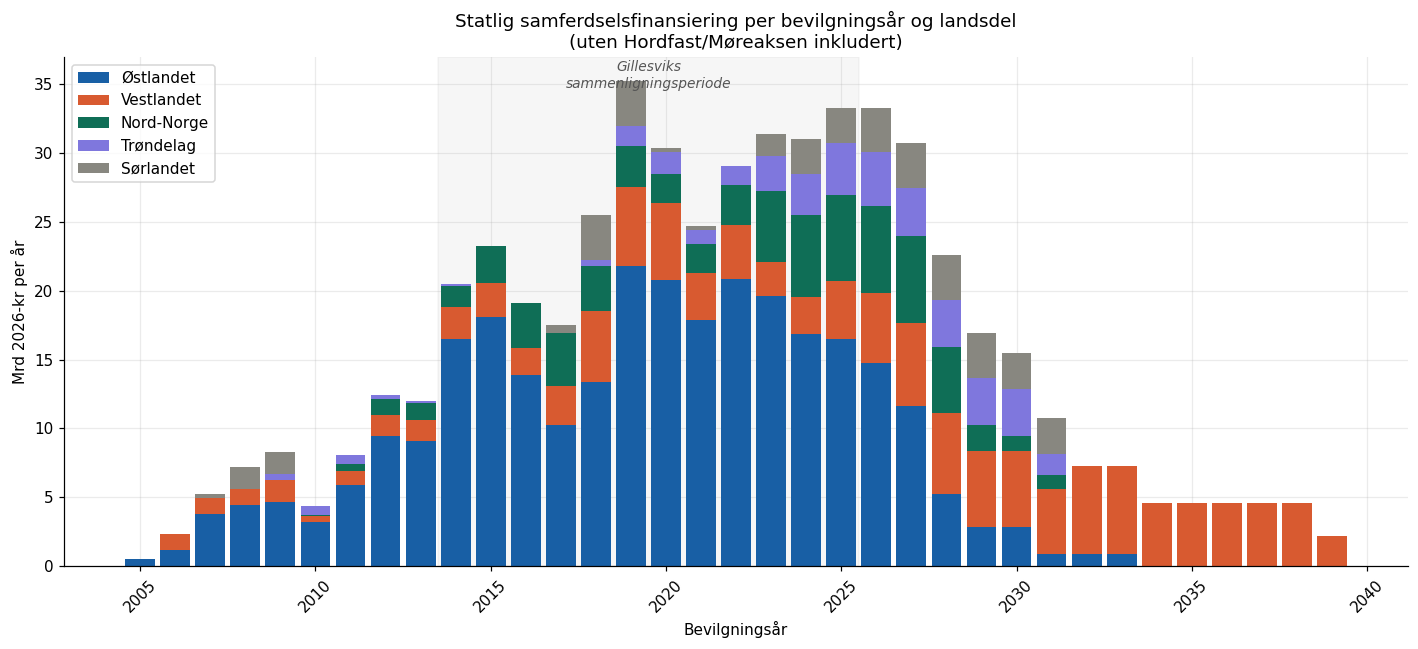

In [408]:
fig, ax = plt.subplots(figsize=(13, 6))

bottom = np.zeros(len(aarlig_df))
for ld in REGIONS:
    vals = aarlig_df[ld].values / 1000
    ax.bar(aarlig_df.index, vals, bottom=bottom, label=RNAVN[ld],
           color=FARGER[ld], width=0.85)
    bottom += vals

ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
tittel = 'Statlig samferdselsfinansiering per bevilgningsår og landsdel'
if INKLUDER_DERSOM:
    tittel += '\n(inkl. Hordfast + Møreaksen)'
else:
    tittel += '\n(uten Hordfast/Møreaksen inkludert)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.legend(loc='upper left', fontsize=10)

# Marker Gillesviks periode
ax.axvspan(2013.5, 2025.5, alpha=0.07, color='gray', zorder=0)
ax.text(2019.5, ax.get_ylim()[1]*0.94, 'Gillesviks\nsammenligningsperiode',
        ha='center', fontsize=9, color='#555', style='italic')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Fordeling BANE / SVV / NV per landsdel (per innbygger per år)

Stablet søylediagram med én søyle per landsdel, delt på virksomhet. Høyden er gjennomsnittlig årlig statlig finansiering per innbygger over analyseperioden. AVINOR er utelatt for å vise vei- og banefordelingen.

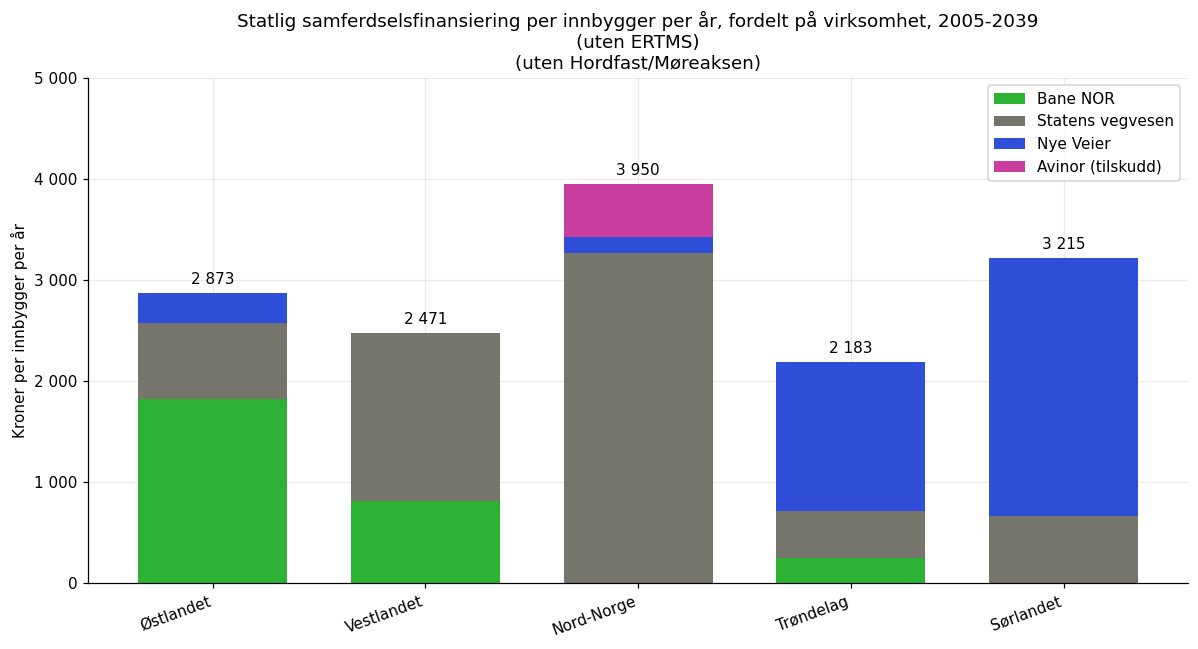

,BANE,SVV,NV,AVINOR
ØST,1821.0,754.0,299.0,0.0
VEST,810.0,1661.0,0.0,0.0
NORD,0.0,3262.0,163.0,525.0
MIDT,250.0,462.0,1471.0,0.0
SØR,0.0,668.0,2547.0,0.0


In [417]:
VIRKSOMHETER = ['BANE', 'SVV', 'NV', 'AVINOR']
VIRKSOMHET_NAVN = {'BANE': 'Bane NOR', 'SVV': 'Statens vegvesen', 'NV': 'Nye Veier', 'AVINOR': 'Avinor (tilskudd)'}
VIRKSOMHET_FARGER = {'BANE': "#2DB334", 'SVV': "#75756B", 'NV': "#304FD8", 'AVINOR': "#CA3EA0"}



# Årlig finansiering per landsdel og virksomhet
virk_aarlig = {v: {r: {} for r in REGIONS} for v in VIRKSOMHETER}
for _, p in df.iterrows():
    if p['virksomhet'] not in VIRKSOMHETER:
        continue
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] == 'HELE_LANDET':
            for r in REGIONS:
                virk_aarlig[p['virksomhet']][r][aar_p] = virk_aarlig[p['virksomhet']][r].get(aar_p, 0) + belop * FOLK[r] / TOTAL_FOLK
        elif p['landsdel'] in REGIONS:
            virk_aarlig[p['virksomhet']][p['landsdel']][aar_p] = virk_aarlig[p['virksomhet']][p['landsdel']].get(aar_p, 0) + belop

# Gjennomsnittlig kr per innbygger per år per landsdel og virksomhet
n_aar = ANALYSE_SLUTT - ANALYSE_START + 1
virk_per_person = pd.DataFrame(index=REGIONS, columns=VIRKSOMHETER, dtype=float)
for v in VIRKSOMHETER:
    for r in REGIONS:
        sum_mill = sum(virk_aarlig[v][r].get(aar, 0) for aar in range(ANALYSE_START, ANALYSE_SLUTT + 1))
        virk_per_person.loc[r, v] = sum_mill * 1_000_000 / FOLK[r] / n_aar

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(REGIONS))
x = np.arange(len(REGIONS))
for v in VIRKSOMHETER:
    vals = virk_per_person[v].values
    ax.bar(x, vals, bottom=bottom, label=VIRKSOMHET_NAVN[v], color=VIRKSOMHET_FARGER[v], width=0.7)
    bottom += vals

for xi, total in zip(x, bottom):
    ax.annotate(
        f'{total:,.0f}'.replace(',', ' '),
        xy=(xi, total),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='500',
    )

ax.set_xticks(x)
ax.set_xticklabels([RNAVN[ld] for ld in REGIONS], rotation=20, ha='right')
ax.set_ylabel('Kroner per innbygger per år')
tittel = f'Statlig samferdselsfinansiering per innbygger per år, fordelt på virksomhet, {ANALYSE_START}-{ANALYSE_SLUTT}'
if not INKLUDER_ERTMS:
    tittel += '\n(uten ERTMS)'
if not INKLUDER_DERSOM:
    tittel += '\n(uten Hordfast/Møreaksen)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', ' ')))
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 5000)
plt.tight_layout()
plt.show()

virk_per_person.round(0)

## 7. SVV-bidrag per år

Viser hvor mye Statens vegvesen bidrar med årlig totalt, og hvordan SVV-bidraget fordeler seg mellom landsdelene.

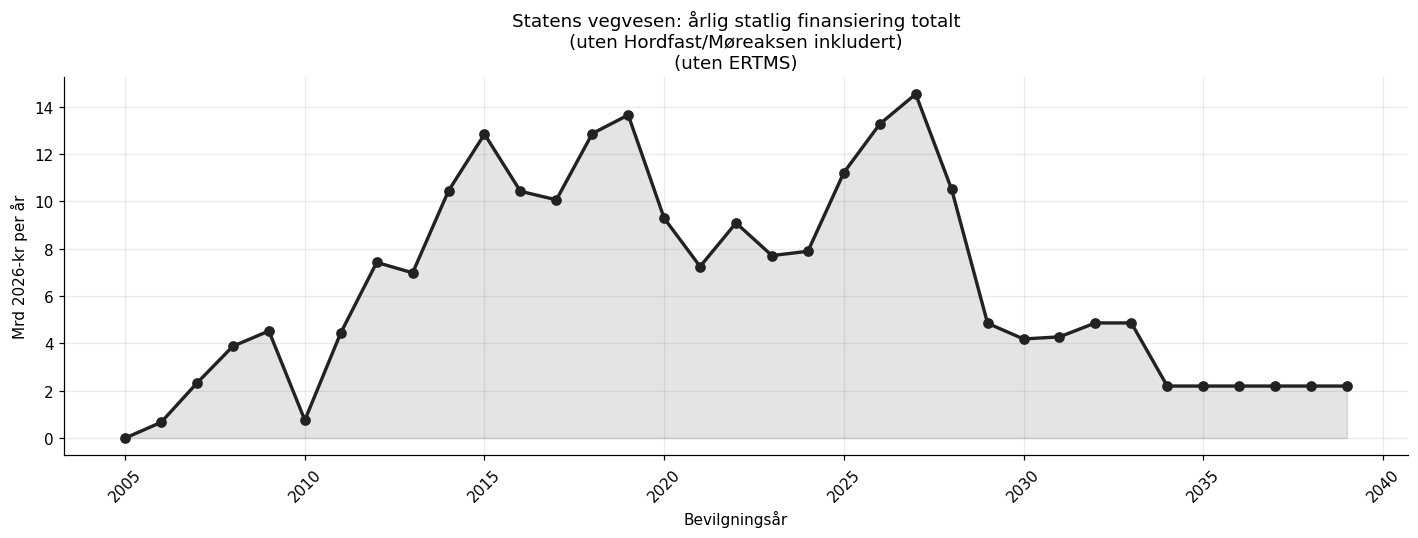

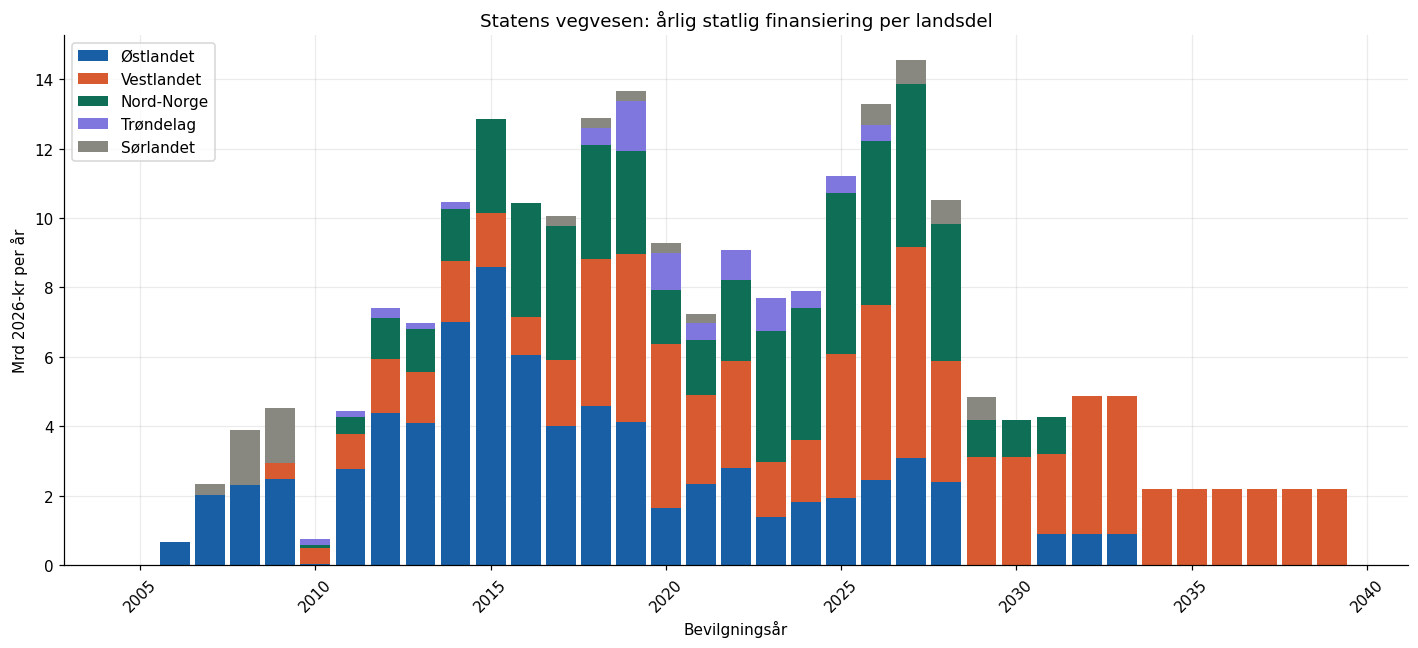

SVV-prosjekter i beregningen: 95


,ØST,VEST,NORD,MIDT,SØR,TOTAL
2005,0.0,0.0,0.0,0.0,0.0,0.0
2006,665.7,0.0,0.0,0.0,0.0,665.7
2007,2016.0,0.0,0.0,0.0,313.0,2329.0
2008,2317.7,0.0,0.0,0.0,1566.0,3883.7
2009,2482.7,476.0,0.0,0.0,1566.0,4524.7
2010,27.8,476.0,74.8,178.2,0.0,756.8
2011,2761.5,1022.2,478.6,184.2,0.0,4446.5
2012,4399.1,1546.9,1181.3,296.2,0.0,7423.6
2013,4091.4,1485.9,1228.3,178.2,0.0,6983.8
2014,6994.6,1775.6,1505.0,178.2,0.0,10453.4


In [410]:
svv_df = df[df['virksomhet'] == 'SVV'].copy()

svv_aarlig = {r: {} for r in REGIONS}
for _, p in svv_df.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] == 'HELE_LANDET':
            for r in REGIONS:
                svv_aarlig[r][aar_p] = svv_aarlig[r].get(aar_p, 0) + belop * FOLK[r] / TOTAL_FOLK
        elif p['landsdel'] in REGIONS:
            svv_aarlig[p['landsdel']][aar_p] = svv_aarlig[p['landsdel']].get(aar_p, 0) + belop

svv_aarlig_df = pd.DataFrame(svv_aarlig).fillna(0).sort_index().reindex(aarlig_df.index, fill_value=0)
svv_aarlig_df['TOTAL'] = svv_aarlig_df[REGIONS].sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    svv_aarlig_df.index,
    svv_aarlig_df['TOTAL'] / 1000,
    marker='o',
    lw=2.2,
    color='#222222',
)
ax.fill_between(svv_aarlig_df.index, svv_aarlig_df['TOTAL'] / 1000, alpha=0.12, color='#222222')
ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
tittel = 'Statens vegvesen: årlig statlig finansiering totalt'
if not INKLUDER_DERSOM:
    tittel += '\n(uten Hordfast/Møreaksen inkludert)'
if not INKLUDER_ERTMS:
    tittel += '\n(uten ERTMS)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(svv_aarlig_df))
for ld in REGIONS:
    vals = svv_aarlig_df[ld].values / 1000
    ax.bar(
        svv_aarlig_df.index,
        vals,
        bottom=bottom,
        label=RNAVN[ld],
        color=FARGER[ld],
        width=0.85,
    )
    bottom += vals

ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
ax.set_title('Statens vegvesen: årlig statlig finansiering per landsdel', fontsize=12, fontweight='500')
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'SVV-prosjekter i beregningen: {len(svv_df)}')
svv_aarlig_df.round(1).head(15)

### SVV med Hordfast og Møreaksen

Samme SVV-plott, men med E39 Hordfast og E39 Møreaksen lagt inn i årsfordelingen.

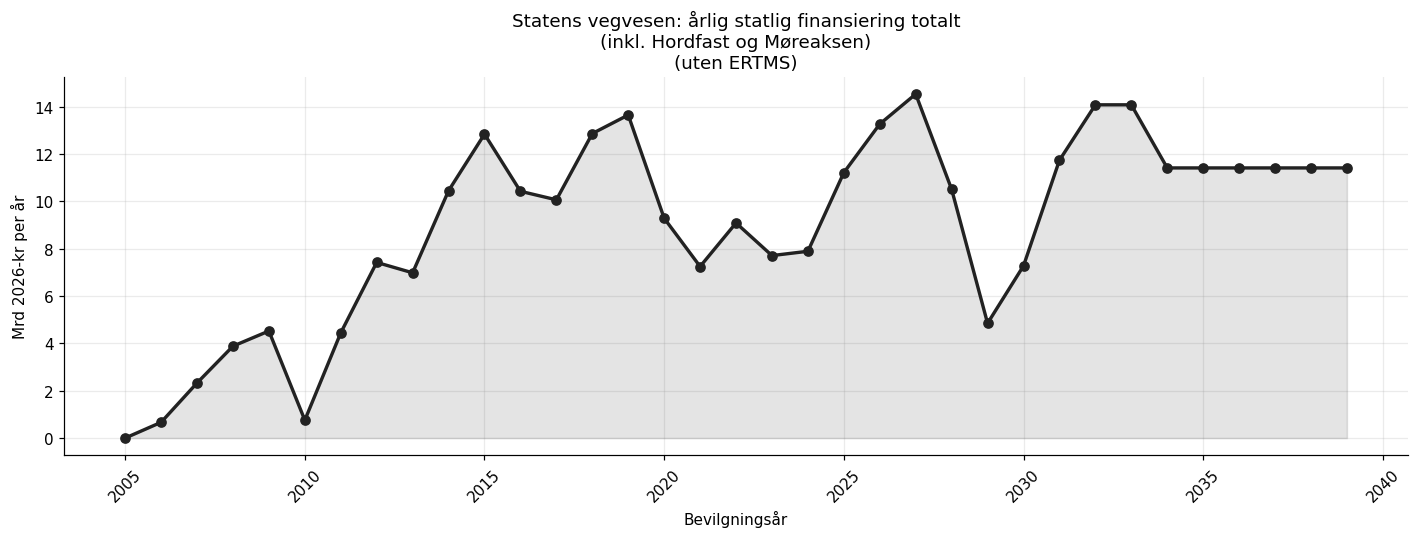

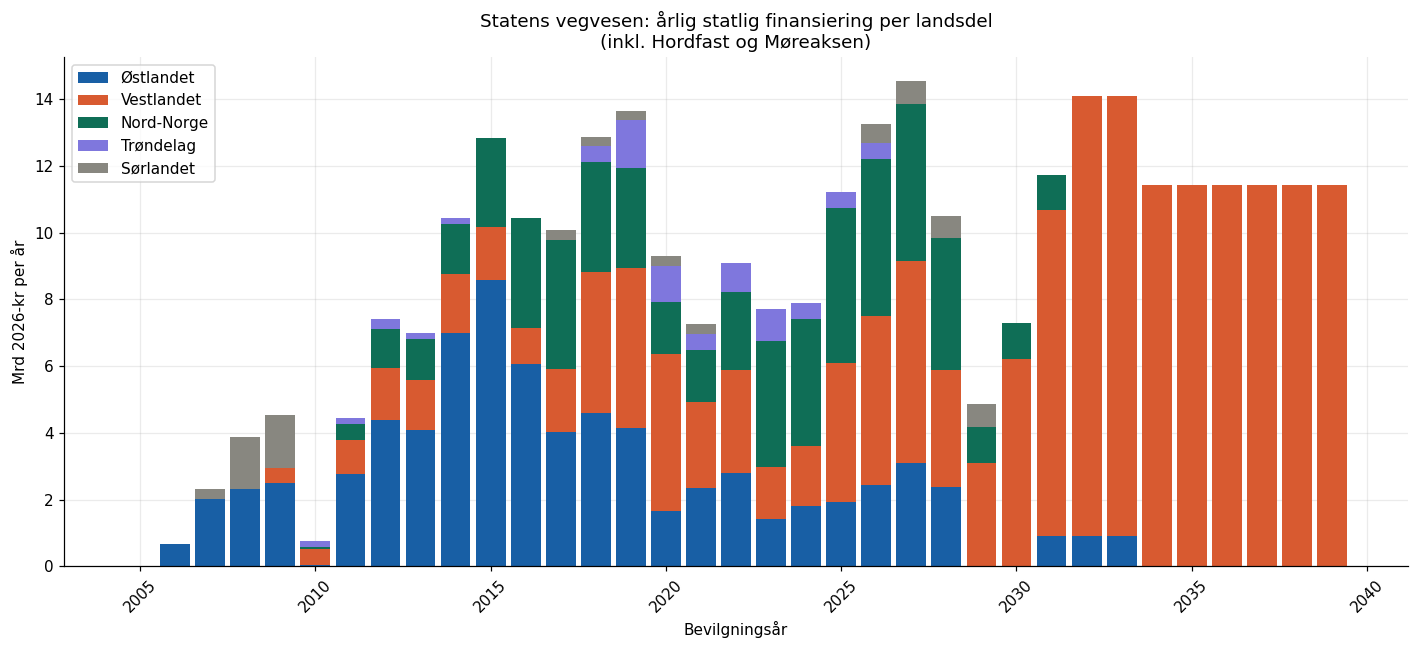

Inkluderte placeholder-prosjekter:
virksomhet          navn landsdel  oppstart_aar  aar_ferdig  statlig_2026kr
       SVV  E39 Hordfast     VEST        2029.0      2039.0         62000.0
       SVV E39 Møreaksen     VEST        2029.0      2039.0         22300.0



,ØST,VEST,NORD,MIDT,SØR,TOTAL
2025,1938.0,4160.3,4633.4,486.3,0.0,11218.0
2026,2447.6,5059.4,4699.8,486.3,577.8,13270.9
2027,3087.3,6070.6,4699.8,0.0,680.8,14538.5
2028,2388.9,3486.6,3956.2,0.0,680.8,10512.4
2029,0.0,3110.1,1060.1,0.0,680.8,4850.9
2030,17.3,6201.0,1060.1,0.0,0.0,7278.4
2031,898.6,9781.6,1060.1,0.0,0.0,11740.3
2032,898.6,13185.0,0.0,0.0,0.0,14083.5
2033,898.6,13185.0,0.0,0.0,0.0,14083.5
2034,0.0,11416.3,0.0,0.0,0.0,11416.3


In [411]:
svv_hm_df = rens_numeriske(df_raw[DERSOM_MASK & (df_raw['virksomhet'] == 'SVV')].copy())

svv_aarlig_hm = {ld: svv_aarlig_df[ld].to_dict() for ld in REGIONS}
for _, p in svv_hm_df.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] in REGIONS:
            svv_aarlig_hm[p['landsdel']][aar_p] = svv_aarlig_hm[p['landsdel']].get(aar_p, 0) + belop

svv_aarlig_hm_df = pd.DataFrame(svv_aarlig_hm).fillna(0).sort_index().reindex(aarlig_df.index, fill_value=0)
svv_aarlig_hm_df['TOTAL'] = svv_aarlig_hm_df[REGIONS].sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    svv_aarlig_hm_df.index,
    svv_aarlig_hm_df['TOTAL'] / 1000,
    marker='o',
    lw=2.2,
    color='#222222',
)
ax.fill_between(svv_aarlig_hm_df.index, svv_aarlig_hm_df['TOTAL'] / 1000, alpha=0.12, color='#222222')
ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
tittel = 'Statens vegvesen: årlig statlig finansiering totalt\n(inkl. Hordfast og Møreaksen)'
if not INKLUDER_ERTMS:
    tittel += '\n(uten ERTMS)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(svv_aarlig_hm_df))
for ld in REGIONS:
    vals = svv_aarlig_hm_df[ld].values / 1000
    ax.bar(
        svv_aarlig_hm_df.index,
        vals,
        bottom=bottom,
        label=RNAVN[ld],
        color=FARGER[ld],
        width=0.85,
    )
    bottom += vals

ax.set_ylabel('Mrd 2026-kr per år')
ax.set_xlabel('Bevilgningsår')
ax.set_title('Statens vegvesen: årlig statlig finansiering per landsdel\n(inkl. Hordfast og Møreaksen)', fontsize=12, fontweight='500')
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Inkluderte placeholder-prosjekter:')
print(svv_hm_df[['virksomhet', 'navn', 'landsdel', 'oppstart_aar', 'aar_ferdig', 'statlig_2026kr']].to_string(index=False))
print()
svv_aarlig_hm_df.round(1).tail(15)


## 8. Vestlandets andel per 3-årsperiode

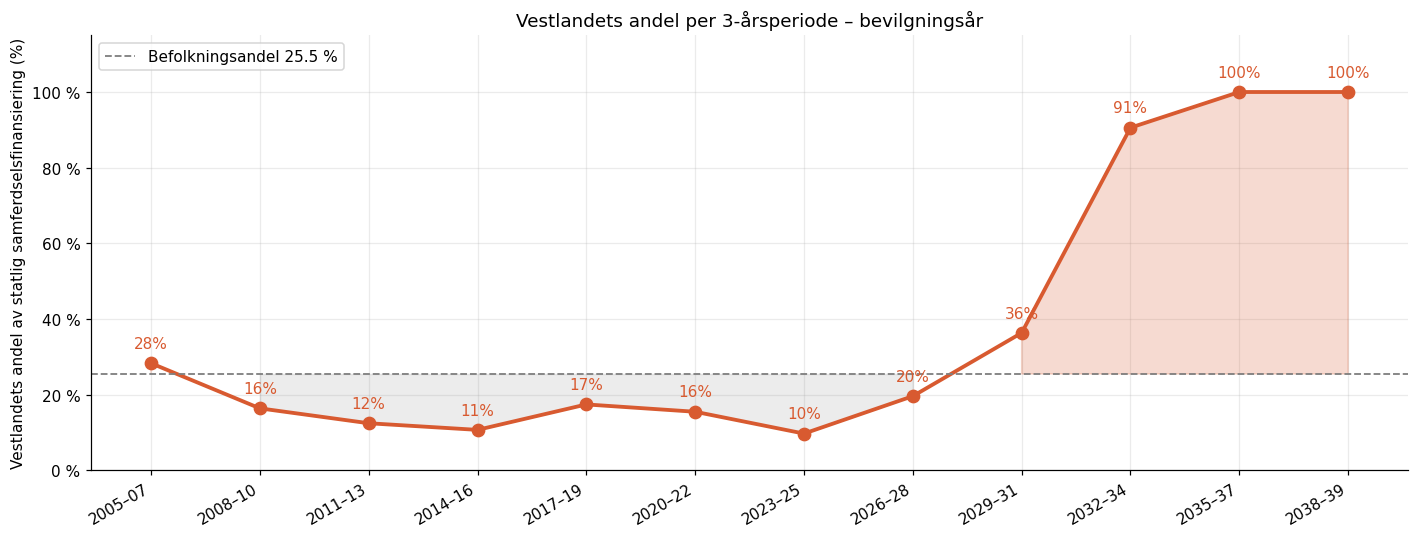

In [412]:
perioder = [(s, min(s + 2, ANALYSE_SLUTT)) for s in range(ANALYSE_START, ANALYSE_SLUTT + 1, 3)]
labels = [f'{s}–{str(e)[-2:]}' for s, e in perioder]
vest_pcts = []
for s, e in perioder:
    sub = aarlig_df.loc[s:e]
    tot = sub[REGIONS].sum().sum()
    vest = sub['VEST'].sum()
    vest_pcts.append(vest/tot*100 if tot > 0 else 0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(range(len(perioder)), vest_pcts, BEF['VEST'],
                where=[v > BEF['VEST'] for v in vest_pcts],
                alpha=0.22, color=FARGER['VEST'])
ax.fill_between(range(len(perioder)), vest_pcts, BEF['VEST'],
                where=[v <= BEF['VEST'] for v in vest_pcts],
                alpha=0.15, color='gray')
ax.plot(range(len(perioder)), vest_pcts, 'o-',
        color=FARGER['VEST'], lw=2.5, ms=8)
ax.axhline(BEF['VEST'], color='gray', lw=1.2, ls='--',
           label=f'Befolkningsandel {BEF["VEST"]:.1f} %')

for i, v in enumerate(vest_pcts):
    ax.annotate(f'{v:.0f}%', xy=(i,v), xytext=(0,10), textcoords='offset points',
                ha='center', fontsize=10, color=FARGER['VEST'])

ax.set_xticks(range(len(perioder)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Vestlandets andel av statlig samferdselsfinansiering (%)')
tittel = 'Vestlandets andel per 3-årsperiode – bevilgningsår'
if INKLUDER_DERSOM:
    tittel += '\n(inkl. Hordfast + Møreaksen)'
ax.set_title(tittel, fontsize=12, fontweight='500')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)} %'))
ax.legend(fontsize=10)
ax.set_ylim(0, max(vest_pcts)*1.15)
plt.tight_layout()
plt.show()

## 9. Sammenligning med Gillesviks tall (2014-2025)

In [413]:
print('='*75)
print(f'STATLIG FINANSIERING 2014-2025 (bevilgningsår, lineær fordeling)')
print(f'INKLUDER_DERSOM = {INKLUDER_DERSOM}')
print('='*75)
print()

sum_14_25 = {ld: aarlig_df.loc[2014:2025, ld].sum() for ld in REGIONS}
total_14_25 = sum(sum_14_25.values())

print(f'{"Landsdel":<13} {"Mrd":>9} {"Andel":>8} {"Bef%":>7} {"Avvik":>10}')
print('-'*53)
for ld in REGIONS:
    andel = sum_14_25[ld]/total_14_25*100
    avvik = andel - BEF[ld]
    print(f'{RNAVN[ld]:<13} {sum_14_25[ld]/1000:>7.1f}m {andel:>6.1f}% {BEF[ld]:>6.1f}% {avvik:>+9.1f}pp')
print('-'*53)
print(f'{"TOTAL":<13} {total_14_25/1000:>7.1f}m')

print()
print('Gillesviks tall (sammenligning):')
print('  ØST: 145 mrd (Intercity 103) = 61,2%')
print('  VEST: 29 mrd (SVV 17 + NV 12) = 14,4%')

STATLIG FINANSIERING 2014-2025 (bevilgningsår, lineær fordeling)
INKLUDER_DERSOM = False

Landsdel            Mrd    Andel    Bef%      Avvik
-----------------------------------------------------
Østlandet       206.3m   64.3%   51.5%     +12.8pp
Vestlandet       42.7m   13.3%   25.5%     -12.2pp
Nord-Norge       42.0m   13.1%    8.6%      +4.5pp
Trøndelag        15.2m    4.7%    8.6%      -3.9pp
Sørlandet        14.4m    4.5%    5.7%      -1.2pp
-----------------------------------------------------
TOTAL           320.7m

Gillesviks tall (sammenligning):
  ØST: 145 mrd (Intercity 103) = 61,2%
  VEST: 29 mrd (SVV 17 + NV 12) = 14,4%


### Ferdigstilte prosjekter 2014–2025 (Gillesvik-stil)

Samme oppsett som Gillesviks figur: prosjekter som ble **ferdigstilt** i perioden 2014–2025 (`aar_ferdig`), med statlig finansiering (mrd. kr), antall prosjekter og andel (%) per landsdel. Hele det statlige beløpet telles i ferdigstillingsåret, ikke fordelt over byggeperioden.

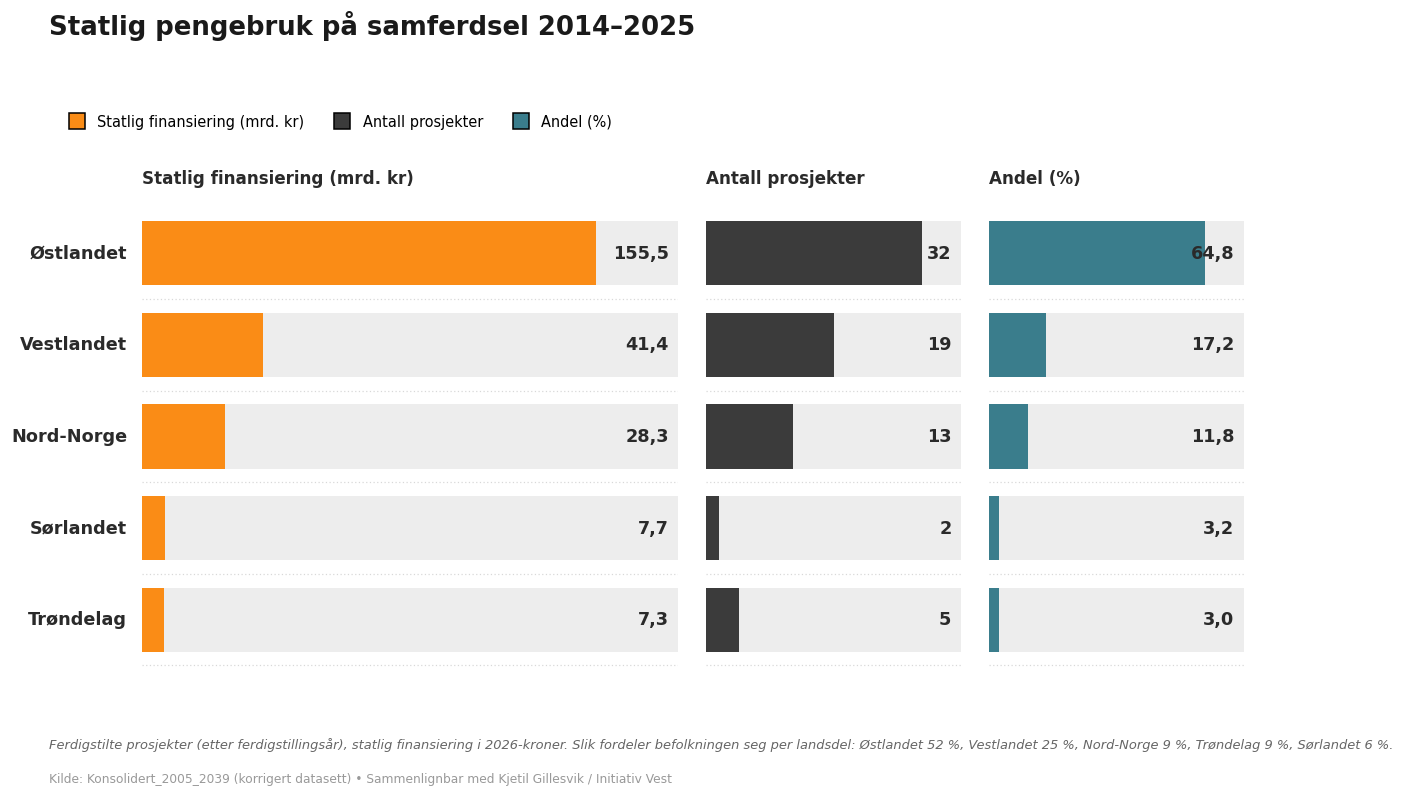

,mrd,antall,andel
landsdel,,,
ØST,155.5,32,64.8
VEST,41.4,19,17.2
NORD,28.3,13,11.8
SØR,7.7,2,3.2
MIDT,7.3,5,3.0


In [420]:
FERDIG_START, FERDIG_SLUTT = 2014, 2025

# Datawrapper-farger
DW_ORANGE = '#fa8c16'
DW_DARK = '#3b3b3b'
DW_TEAL = '#3a7d8c'
DW_TRACK = '#ededed'      # lysegrått bakgrunnsspor
DW_TEKST = '#2a2a2a'
DW_GRA = '#8a8a8a'

ferdig_df = df[(df['aar_ferdig'] >= FERDIG_START) & (df['aar_ferdig'] <= FERDIG_SLUTT)].copy()
ferdig_df = ferdig_df[ferdig_df['statlig_2026kr'] > 0]

ferdig_oppsummering = (
    ferdig_df.groupby('landsdel')
    .agg(mrd=('statlig_2026kr', lambda s: s.sum() / 1000), antall=('navn', 'count'))
)
ferdig_oppsummering = ferdig_oppsummering.reindex([ld for ld in REGIONS if ld in ferdig_oppsummering.index])
ferdig_oppsummering['andel'] = ferdig_oppsummering['mrd'] / ferdig_oppsummering['mrd'].sum() * 100
ferdig_oppsummering = ferdig_oppsummering.sort_values('mrd', ascending=False)

navn_rekke = [RNAVN[ld] for ld in ferdig_oppsummering.index]
n = len(ferdig_oppsummering)
y = np.arange(n)[::-1]  # øverste verdi øverst

paneler = [
    ('mrd', 'Statlig finansiering (mrd. kr)', DW_ORANGE, lambda v: f'{v:,.1f}'.replace(',', ' ').replace('.', ',')),
    ('antall', 'Antall prosjekter', DW_DARK, lambda v: f'{int(v)}'),
    ('andel', 'Andel (%)', DW_TEAL, lambda v: f'{v:.1f}'.replace('.', ',')),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 0.82 * n + 2.0),
                         gridspec_kw={'width_ratios': [2.1, 1.0, 1.0], 'wspace': 0.08})

for ax, (kol, kol_tittel, farge, fmt) in zip(axes, paneler):
    maks = ferdig_oppsummering[kol].max()
    spor_lengde = maks * 1.18
    # Lysegrått bakgrunnsspor
    ax.barh(y, [spor_lengde] * n, color=DW_TRACK, height=0.7, zorder=1)
    # Verdisøyle
    ax.barh(y, ferdig_oppsummering[kol], color=farge, height=0.7, zorder=2)
    # Verditall ved enden av sporet (mørk, høyrejustert)
    for yi, val in zip(y, ferdig_oppsummering[kol]):
        ax.annotate(fmt(val), xy=(spor_lengde, yi), xytext=(-6, 0),
                    textcoords='offset points', ha='right', va='center',
                    fontsize=11.5, fontweight='600', color=DW_TEKST, zorder=3)
    ax.set_xlim(0, spor_lengde)
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_title(kol_tittel, fontsize=11, fontweight='600', loc='left', color=DW_TEKST, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

# Radetiketter til venstre + stiplede radskiller på tvers av alle paneler
for yi, navn in zip(y, navn_rekke):
    axes[0].annotate(navn, xy=(0, yi), xytext=(-10, 0), textcoords='offset points',
                     ha='right', va='center', fontsize=11.5, fontweight='700', color=DW_TEKST,
                     annotation_clip=False)
for ax in axes:
    for yi in y:
        ax.axhline(yi - 0.5, color='#d8d8d8', lw=0.8, ls=(0, (1, 2)), zorder=0)

# Fargeforklaring øverst
handles = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_ORANGE, markersize=11, label='Statlig finansiering (mrd. kr)'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_DARK, markersize=11, label='Antall prosjekter'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_TEAL, markersize=11, label='Andel (%)'),
]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.065, 0.965),
           frameon=False, ncol=3, fontsize=9.5, handletextpad=0.4, columnspacing=1.6)

fig.suptitle(f'Statlig pengebruk på samferdsel {FERDIG_START}–{FERDIG_SLUTT}',
             fontsize=17, fontweight='800', x=0.065, ha='left', y=1.10, color='#1a1a1a')

fig.text(0.065, 0.0,
         'Ferdigstilte prosjekter (etter ferdigstillingsår), statlig finansiering i 2026-kroner. Slik fordeler '
         f'befolkningen seg per landsdel: {", ".join(f"{RNAVN[ld]} {BEF[ld]:.0f} %" for ld in REGIONS)}.',
         ha='left', fontsize=8.5, style='italic', color='#666666')
fig.text(0.065, -0.05,
         'Kilde: Konsolidert_2005_2039 (korrigert datasett) • Sammenlignbar med Kjetil Gillesvik / Initiativ Vest',
         ha='left', fontsize=8, color='#999999')

plt.subplots_adjust(top=0.82, left=0.13)
plt.show()

ferdig_oppsummering.assign(
    mrd=ferdig_oppsummering['mrd'].round(1),
    andel=ferdig_oppsummering['andel'].round(1),
)

### Pengebruk 2014–2025 – årlig fordelt (også pågående prosjekter)

Samme Datawrapper-stil, men her telles **årlig fordelt statlig finansiering** i perioden 2014–2025 (via `fordel_per_aar`), uavhengig av om prosjektet er ferdigstilt. Et prosjekt som bygges 2022–2030 bidrar dermed med sine 2022–2025-andeler. Antall prosjekter teller alle med fordelt beløp i vinduet.

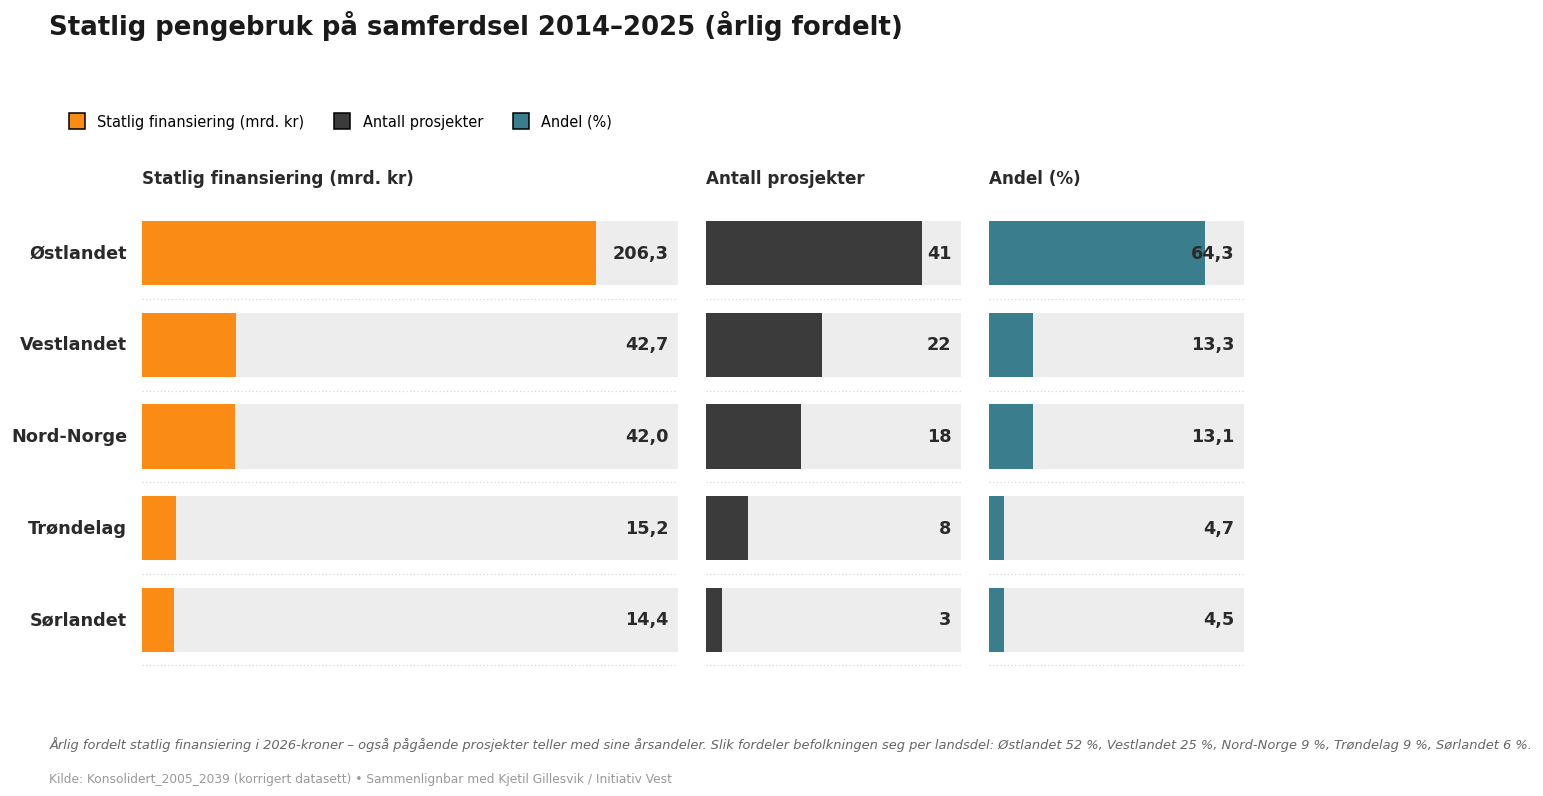

,mrd,antall,andel
ØST,206.3,41,64.3
VEST,42.7,22,13.3
NORD,42.0,18,13.1
MIDT,15.2,8,4.7
SØR,14.4,3,4.5


In [421]:
FORDELT_START, FORDELT_SLUTT = 2014, 2025

# Beløp: årlig fordelt finansiering summert over vinduet (bruker aarlig_df, som følger config)
fordelt_mrd = {ld: aarlig_df.loc[FORDELT_START:FORDELT_SLUTT, ld].sum() / 1000 for ld in REGIONS}

# Antall prosjekter med fordelt beløp i vinduet
fordelt_antall = {ld: 0 for ld in REGIONS}
for _, p in df.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    belop_i_vindu = sum(b for a, b in fordel.items() if FORDELT_START <= a <= FORDELT_SLUTT)
    if belop_i_vindu <= 0:
        continue
    if p['landsdel'] in REGIONS:
        fordelt_antall[p['landsdel']] += 1
    elif p['landsdel'] == 'HELE_LANDET':
        for ld in REGIONS:
            fordelt_antall[ld] += 1

fordelt_oppsummering = pd.DataFrame({'mrd': fordelt_mrd, 'antall': fordelt_antall})
fordelt_oppsummering = fordelt_oppsummering[fordelt_oppsummering['mrd'] > 0]
fordelt_oppsummering['andel'] = fordelt_oppsummering['mrd'] / fordelt_oppsummering['mrd'].sum() * 100
fordelt_oppsummering = fordelt_oppsummering.sort_values('mrd', ascending=False)

# Datawrapper-farger (samme som forrige figur)
DW_ORANGE = '#fa8c16'
DW_DARK = '#3b3b3b'
DW_TEAL = '#3a7d8c'
DW_TRACK = '#ededed'
DW_TEKST = '#2a2a2a'

navn_rekke = [RNAVN[ld] for ld in fordelt_oppsummering.index]
n = len(fordelt_oppsummering)
y = np.arange(n)[::-1]

paneler = [
    ('mrd', 'Statlig finansiering (mrd. kr)', DW_ORANGE, lambda v: f'{v:,.1f}'.replace(',', ' ').replace('.', ',')),
    ('antall', 'Antall prosjekter', DW_DARK, lambda v: f'{int(v)}'),
    ('andel', 'Andel (%)', DW_TEAL, lambda v: f'{v:.1f}'.replace('.', ',')),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 0.82 * n + 2.0),
                         gridspec_kw={'width_ratios': [2.1, 1.0, 1.0], 'wspace': 0.08})

for ax, (kol, kol_tittel, farge, fmt) in zip(axes, paneler):
    maks = fordelt_oppsummering[kol].max()
    spor_lengde = maks * 1.18
    ax.barh(y, [spor_lengde] * n, color=DW_TRACK, height=0.7, zorder=1)
    ax.barh(y, fordelt_oppsummering[kol], color=farge, height=0.7, zorder=2)
    for yi, val in zip(y, fordelt_oppsummering[kol]):
        ax.annotate(fmt(val), xy=(spor_lengde, yi), xytext=(-6, 0),
                    textcoords='offset points', ha='right', va='center',
                    fontsize=11.5, fontweight='600', color=DW_TEKST, zorder=3)
    ax.set_xlim(0, spor_lengde)
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_title(kol_tittel, fontsize=11, fontweight='600', loc='left', color=DW_TEKST, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

for yi, navn in zip(y, navn_rekke):
    axes[0].annotate(navn, xy=(0, yi), xytext=(-10, 0), textcoords='offset points',
                     ha='right', va='center', fontsize=11.5, fontweight='700', color=DW_TEKST,
                     annotation_clip=False)
for ax in axes:
    for yi in y:
        ax.axhline(yi - 0.5, color='#d8d8d8', lw=0.8, ls=(0, (1, 2)), zorder=0)

handles = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_ORANGE, markersize=11, label='Statlig finansiering (mrd. kr)'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_DARK, markersize=11, label='Antall prosjekter'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_TEAL, markersize=11, label='Andel (%)'),
]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.065, 0.965),
           frameon=False, ncol=3, fontsize=9.5, handletextpad=0.4, columnspacing=1.6)

fig.suptitle(f'Statlig pengebruk på samferdsel {FORDELT_START}–{FORDELT_SLUTT} (årlig fordelt)',
             fontsize=17, fontweight='800', x=0.065, ha='left', y=1.10, color='#1a1a1a')

fig.text(0.065, 0.0,
         'Årlig fordelt statlig finansiering i 2026-kroner – også pågående prosjekter teller med sine årsandeler. '
         f'Slik fordeler befolkningen seg per landsdel: {", ".join(f"{RNAVN[ld]} {BEF[ld]:.0f} %" for ld in REGIONS)}.',
         ha='left', fontsize=8.5, style='italic', color='#666666')
fig.text(0.065, -0.05,
         'Kilde: Konsolidert_2005_2039 (korrigert datasett) • Sammenlignbar med Kjetil Gillesvik / Initiativ Vest',
         ha='left', fontsize=8, color='#999999')

plt.subplots_adjust(top=0.82, left=0.13)
plt.show()

fordelt_oppsummering.assign(
    mrd=fordelt_oppsummering['mrd'].round(1),
    andel=fordelt_oppsummering['andel'].round(1),
)

### Pengebruk 2005–2039 – årlig fordelt (hele perioden)

Samme Datawrapper-stil og metode (årlig fordelt statlig finansiering via `fordel_per_aar`), men for hele analyseperioden 2005–2039.

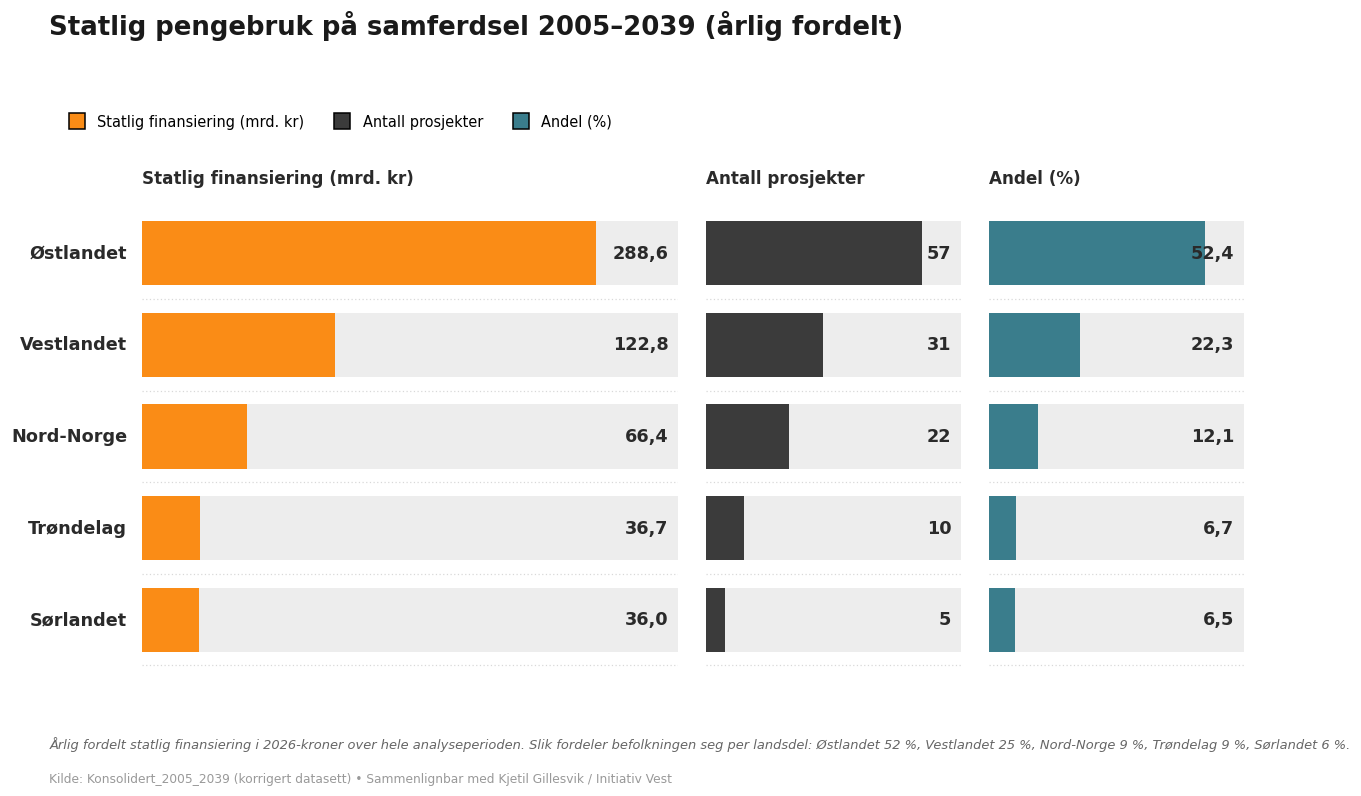

,mrd,antall,andel
ØST,288.6,57,52.4
VEST,122.8,31,22.3
NORD,66.4,22,12.1
MIDT,36.7,10,6.7
SØR,36.0,5,6.5


In [422]:
HELE_START, HELE_SLUTT = ANALYSE_START, ANALYSE_SLUTT

# Beløp: årlig fordelt finansiering summert over hele perioden (bruker aarlig_df, som følger config)
hele_mrd = {ld: aarlig_df.loc[HELE_START:HELE_SLUTT, ld].sum() / 1000 for ld in REGIONS}

# Antall prosjekter med fordelt beløp i perioden
hele_antall = {ld: 0 for ld in REGIONS}
for _, p in df.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0:
        continue
    fordel = fordel_per_aar(p)
    belop_i_vindu = sum(b for a, b in fordel.items() if HELE_START <= a <= HELE_SLUTT)
    if belop_i_vindu <= 0:
        continue
    if p['landsdel'] in REGIONS:
        hele_antall[p['landsdel']] += 1
    elif p['landsdel'] == 'HELE_LANDET':
        for ld in REGIONS:
            hele_antall[ld] += 1

hele_oppsummering = pd.DataFrame({'mrd': hele_mrd, 'antall': hele_antall})
hele_oppsummering = hele_oppsummering[hele_oppsummering['mrd'] > 0]
hele_oppsummering['andel'] = hele_oppsummering['mrd'] / hele_oppsummering['mrd'].sum() * 100
hele_oppsummering = hele_oppsummering.sort_values('mrd', ascending=False)

# Datawrapper-farger (samme som forrige figur)
DW_ORANGE = '#fa8c16'
DW_DARK = '#3b3b3b'
DW_TEAL = '#3a7d8c'
DW_TRACK = '#ededed'
DW_TEKST = '#2a2a2a'

navn_rekke = [RNAVN[ld] for ld in hele_oppsummering.index]
n = len(hele_oppsummering)
y = np.arange(n)[::-1]

paneler = [
    ('mrd', 'Statlig finansiering (mrd. kr)', DW_ORANGE, lambda v: f'{v:,.1f}'.replace(',', ' ').replace('.', ',')),
    ('antall', 'Antall prosjekter', DW_DARK, lambda v: f'{int(v)}'),
    ('andel', 'Andel (%)', DW_TEAL, lambda v: f'{v:.1f}'.replace('.', ',')),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 0.82 * n + 2.0),
                         gridspec_kw={'width_ratios': [2.1, 1.0, 1.0], 'wspace': 0.08})

for ax, (kol, kol_tittel, farge, fmt) in zip(axes, paneler):
    maks = hele_oppsummering[kol].max()
    spor_lengde = maks * 1.18
    ax.barh(y, [spor_lengde] * n, color=DW_TRACK, height=0.7, zorder=1)
    ax.barh(y, hele_oppsummering[kol], color=farge, height=0.7, zorder=2)
    for yi, val in zip(y, hele_oppsummering[kol]):
        ax.annotate(fmt(val), xy=(spor_lengde, yi), xytext=(-6, 0),
                    textcoords='offset points', ha='right', va='center',
                    fontsize=11.5, fontweight='600', color=DW_TEKST, zorder=3)
    ax.set_xlim(0, spor_lengde)
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_title(kol_tittel, fontsize=11, fontweight='600', loc='left', color=DW_TEKST, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

for yi, navn in zip(y, navn_rekke):
    axes[0].annotate(navn, xy=(0, yi), xytext=(-10, 0), textcoords='offset points',
                     ha='right', va='center', fontsize=11.5, fontweight='700', color=DW_TEKST,
                     annotation_clip=False)
for ax in axes:
    for yi in y:
        ax.axhline(yi - 0.5, color='#d8d8d8', lw=0.8, ls=(0, (1, 2)), zorder=0)

handles = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_ORANGE, markersize=11, label='Statlig finansiering (mrd. kr)'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_DARK, markersize=11, label='Antall prosjekter'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=DW_TEAL, markersize=11, label='Andel (%)'),
]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.065, 0.965),
           frameon=False, ncol=3, fontsize=9.5, handletextpad=0.4, columnspacing=1.6)

fig.suptitle(f'Statlig pengebruk på samferdsel {HELE_START}–{HELE_SLUTT} (årlig fordelt)',
             fontsize=17, fontweight='800', x=0.065, ha='left', y=1.10, color='#1a1a1a')

fig.text(0.065, 0.0,
         'Årlig fordelt statlig finansiering i 2026-kroner over hele analyseperioden. '
         f'Slik fordeler befolkningen seg per landsdel: {", ".join(f"{RNAVN[ld]} {BEF[ld]:.0f} %" for ld in REGIONS)}.',
         ha='left', fontsize=8.5, style='italic', color='#666666')
fig.text(0.065, -0.05,
         'Kilde: Konsolidert_2005_2039 (korrigert datasett) • Sammenlignbar med Kjetil Gillesvik / Initiativ Vest',
         ha='left', fontsize=8, color='#999999')

plt.subplots_adjust(top=0.82, left=0.13)
plt.show()

hele_oppsummering.assign(
    mrd=hele_oppsummering['mrd'].round(1),
    andel=hele_oppsummering['andel'].round(1),
)

## 10. Effekt av Hordfast/Møreaksen (sammenligning)

Beregner side-om-side hva det betyr å inkludere placeholder-prosjektene.

Placeholder-prosjekter (2):
         navn landsdel  oppstart_aar  aar_ferdig  statlig_2026kr
 E39 Hordfast     VEST        2029.0      2039.0         62000.0
E39 Møreaksen     VEST        2029.0      2039.0         22300.0



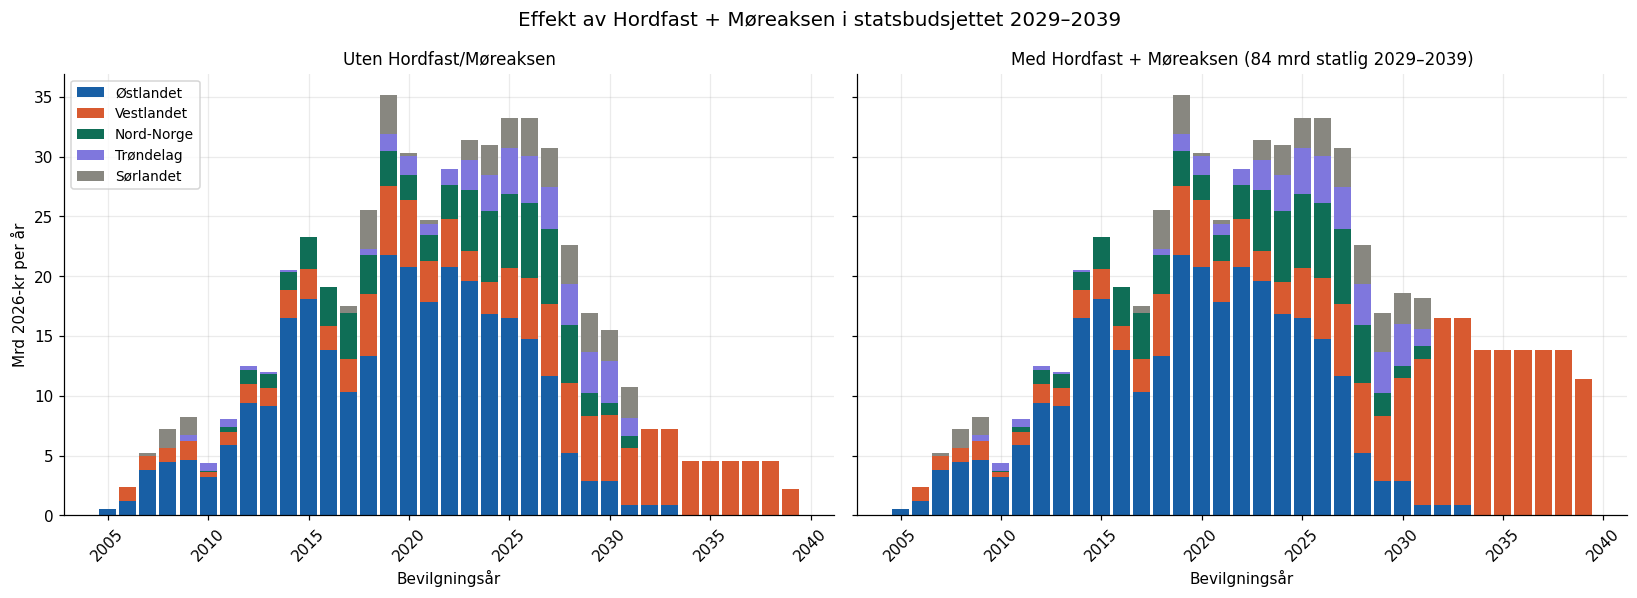


Vestlandets statlige finansiering 2029–2039 (årlig snitt):
  Uten H/M:  4.86 mrd/år
  Med H/M:   12.52 mrd/år
  Effekt:    +7.66 mrd/år


In [414]:
# Hent placeholder-prosjektene fra opprinnelig data
df_dersom = rens_numeriske(df_raw[DERSOM_MASK].copy())

print(f'Placeholder-prosjekter ({len(df_dersom)}):')
print(df_dersom[['navn','landsdel','oppstart_aar','aar_ferdig','statlig_2026kr']].to_string(index=False))
print()

# Beregn med Dersom-prosjekter inkludert
aarlig_med = {r: dict(d) for r, d in aarlig.items()}  # kopier
for _, p in df_dersom.iterrows():
    if pd.isna(p['statlig_2026kr']) or p['statlig_2026kr'] <= 0: continue
    fordel = fordel_per_aar(p)
    for aar_p, belop in fordel.items():
        if p['landsdel'] in REGIONS:
            aarlig_med[p['landsdel']][aar_p] = aarlig_med[p['landsdel']].get(aar_p, 0) + belop

aarlig_med_df = pd.DataFrame(aarlig_med).fillna(0).sort_index().reindex(range(ANALYSE_START, ANALYSE_SLUTT + 1), fill_value=0)

# Side-by-side plott
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

ymax = 0
for ax, data, tittel in zip(axes,
                             [aarlig_df, aarlig_med_df],
                             ['Uten Hordfast/Møreaksen',
                              'Med Hordfast + Møreaksen (84 mrd statlig 2029–2039)']):
    bottom = np.zeros(len(data))
    for ld in REGIONS:
        vals = data[ld].values / 1000
        ax.bar(data.index, vals, bottom=bottom, color=FARGER[ld], width=0.85,
               label=RNAVN[ld] if ax==axes[0] else None)
        bottom += vals
    ymax = max(ymax, bottom.max())
    ax.set_title(tittel, fontsize=11, fontweight='500')
    ax.set_xlabel('Bevilgningsår')
    ax.tick_params(axis='x', rotation=45)

for ax in axes:
    ax.set_ylim(0, ymax*1.05)
axes[0].set_ylabel('Mrd 2026-kr per år')
axes[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Effekt av Hordfast + Møreaksen i statsbudsjettet 2029–2039',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()

# Vestlandets snitt
print()
print(f'Vestlandets statlige finansiering 2029–2039 (årlig snitt):')
uten = aarlig_df.loc[2029:2039, 'VEST'].mean()
med = aarlig_med_df.loc[2029:2039, 'VEST'].mean()
print(f'  Uten H/M:  {uten/1000:.2f} mrd/år')
print(f'  Med H/M:   {med/1000:.2f} mrd/år')
print(f'  Effekt:    +{(med-uten)/1000:.2f} mrd/år')


## 11. Eksporter resultater

In [415]:
aarlig_df.round(1).to_csv('bevilgning_per_aar.csv')
print(f'Eksportert: bevilgning_per_aar.csv ({len(aarlig_df)} år)')

# Per landsdel og 3-årsperiode
periode_df = pd.DataFrame(
    {f'{s}–{str(e)[-2:]}': {ld: aarlig_df.loc[s:e, ld].sum() for ld in REGIONS}
     for s, e in perioder}
).T.round(1)
periode_df['TOTAL'] = periode_df.sum(axis=1)
periode_df['VEST_pct'] = (periode_df['VEST']/periode_df['TOTAL']*100).round(1)
periode_df.to_csv('per_3aars_periode.csv')
print(f'Eksportert: per_3aars_periode.csv')
periode_df

Eksportert: bevilgning_per_aar.csv (35 år)
Eksportert: per_3aars_periode.csv


,ØST,VEST,NORD,MIDT,SØR,TOTAL,VEST_pct
2005–07,5493.1,2295.0,0.0,0.0,313.0,8101.1,28.3
2008–10,12274.2,3247.0,74.8,1062.9,3132.0,19790.9,16.4
2011–13,24469.2,4055.1,2888.2,1100.9,0.0,32513.4,12.5
2014–16,48481.8,6739.4,7474.5,178.2,0.0,62873.9,10.7
2017–19,45429.0,13641.4,10140.5,1904.0,7084.4,78199.3,17.4
2020–22,59420.9,13025.1,7119.8,3866.4,567.6,83999.8,15.5
2023–25,53004.3,9315.3,17286.0,9263.9,6791.1,95660.6,9.7
2026–28,31636.7,16997.8,17375.2,10884.5,9688.7,86582.9,19.6
2029–31,6619.7,15681.9,3999.9,8414.3,8430.2,43146.0,36.3
2032–34,1797.1,17275.5,0.0,0.0,0.0,19072.6,90.6
